# AIFFEL_DLthon_RS18_trackA


## Overview
### Track A — 데이터 정화 & 분류
태양광 패널 이미지를 Clean(깨끗) / Dusty(먼지) 로 분류합니다. 단, 학습 데이터에는 틀린 라벨, 중복 이미지, 패널이 아닌 이미지가 섞여 있습니다. 데이터를 정제해 분류 성능을 높이는 것이 목표입니다.

### 제출 형식 (id, dusty_prob)
- dusty_prob: 이미지가 패널일 때 Dusty일 확률 (0~1)
### 평가
- ROC-AUC: 모델이 Dusty를 Clean보다 높게 점수 매기는 능력

### Evaluation
ROC-AUC score로 측정합니다.

submission.csv
테스트 세트의 각 ID에 대해 Dusty일 확률을 예측해야 합니다. 제출 파일은 다음과 같이 작성되어야 합니다.

id	dusty_prob
test_00000	0.5
test_00001	0.4
test_00002	0.3

## Competition Rules
1. Submission파일에 레이블 생성 후 리더보드에 업로드합니다.
- 리더보드의 점수는 모델 성능 확인/학습의 방향성 설정용입니다.
- 점수만으로 프로젝트 성취를 판단하지 않습니다.
2. 제출 횟수는 하루 5회로 제한됩니다.
3. 마지막날 발표를 기준으로 프로젝트 점수를 부여합니다.
- 역할 분담, 회고 등의 프로젝트 정보와 프로젝트 진행 과정, 실험 내용, 시각화 등 프로젝트 평가 항목에 맞는 발표자료를 준비해주세요.

프로젝트 평가 항목  
- 데이터 EDA와 전처리를 적절히 수행했는가?
- 모델 선정 근거가 타당한가?
- 모델의 성능/학습 방향을 판단하고 개선을 시도한 기준이 논리적인가?
- 결과 도출을 위해 다양한 시도를 했는가?
- 도출된 결론에 충분한 설득력이 있는가?
- 발표 자료가 청자의 입장에서 잘 정리되어있는가?
- 발표가 매끄럽게 진행되었고 발표시간을 준수하였는가?

카글 주소 :  https://www.kaggle.com/competitions/rs-18-track-a/data

In [14]:
!pip install "numpy<2"

In [15]:
!pip install kagglehub

In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import kagglehub
import matplotlib.pyplot as plt

In [17]:


# kaggle.json 파일에 적힌 본인의 username과 key를 입력하세요
os.environ['KAGGLE_USERNAME'] = "as9864"
os.environ['KAGGLE_KEY'] = "17ea3b3c355ae8c3c5e06df3033f539d"

# Download latest version
path = kagglehub.competition_download('rs-18-track-a')

print("Path to competition files:", path)

Path to competition files: C:\Users\H11\.cache\kagglehub\competitions\rs-18-track-a


In [3]:
path = 'C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a'

print(os.listdir(path))

['sample_submission.csv', 'submission1_original.csv', 'submission2_cleansed_data.csv', 'submission3.csv', 'submission3_cleansed_dataaugmentation.csv', 'submission4_efficient.csv', 'submission_efficient2.csv', 'submission_strategy_A.csv', 'submission_strategy_B.csv', 'submission_strategy_B2.csv', 'submission_strategy_C.csv', 'submission_strategy_C2.csv', 'submission_strategy_D.csv', 'submission_strategy_D2.csv', 'test', 'train', 'train_labels.csv']


In [4]:
path = 'C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a'

# 각 파일의 절대 경로 생성
train_csv_path = os.path.join(path, 'train_labels.csv')
sub_csv_path = os.path.join(path, 'sample_submission.csv')

# Pandas DataFrame으로 읽기
train_df = pd.read_csv(train_csv_path)
sub_df = pd.read_csv(sub_csv_path)

# 데이터 확인
print("--- Train Labels ---")
print(train_df.head())

--- Train Labels ---
            id  label
0  train_00000      0
1  train_00001      1
2  train_00002      0
3  train_00003      1
4  train_00004      1


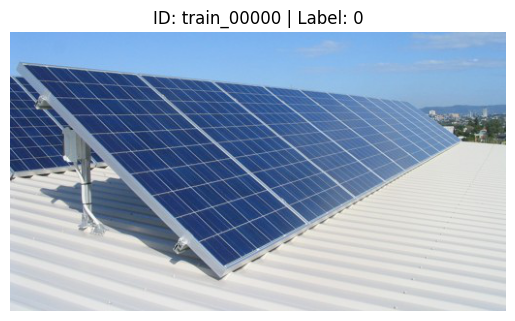

In [20]:

# train 폴더 경로
train_img_dir = os.path.join(path, 'train')

# 첫 번째 데이터 이미지 불러와보기
sample_row = train_df.iloc[0]
sample_id = sample_row['id']      # 예: train_00001
sample_label = sample_row['label'] # 0 (Clean) 또는 1 (Dusty)

# 이미지 전체 경로 (확장자 .jpg 붙이기)
img_path = os.path.join(train_img_dir, f"{sample_id}.jpg")

# 이미지 열기 및 출력
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id} | Label: {sample_label}")
plt.axis('off')
plt.show()

In [5]:
# ==========================================
# 1. 환경 설정 및 하이퍼파라미터
# ==========================================
# path 변수를 실제 데이터가 있는 폴더 경로로 설정해주세요.

path = 'C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a'

# 각 파일의 절대 경로 생성
# train_csv_path = os.path.join(path, 'train_labels.csv')
train_csv_path = './train_SJ_cleaned.csv'
# sub_csv_path = os.path.join(path, 'sample_submission.csv')
# train_csv_path = os.path.join(path, 'train_labels.csv')
sub_csv_path = os.path.join(path, 'sample_submission.csv')
train_img_dir = os.path.join(path, 'train')
test_img_dir = os.path.join(path, 'test') # 테스트 이미지 폴더 경로 가정

BATCH_SIZE = 32
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. 커스텀 Dataset 클래스 정의
# ==========================================
class SolarPanelDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id']
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        
        # RGB로 변환하여 흑백 이미지 등의 채널 오류 방지
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        if self.is_test:
            return image, img_id
        else:
            label = self.df.iloc[idx]['label']
            return image, torch.tensor(label, dtype=torch.float32)

# ==========================================
# 3. 데이터 로더 및 전처리 준비
# ==========================================
# 학습용 데이터 증강 및 전처리

import torch
from torchvision import transforms

# ==========================================
# 1. Train 데이터 전처리 (강력한 Augmentation 적용)
# ==========================================
train_transform = transforms.Compose([
    # 1. 크기 변형: 이미지를 무작위로 자른 후 224x224로 맞춤 (가장 효과가 좋은 기본 증강)
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), ratio=(0.8, 1.2)),
    
    # 2. 좌우 반전: 50% 확률로 뒤집기
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 3. 색상 왜곡: 밝기, 대비, 채도를 무작위로 미세하게 조절
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ], p=0.3),
    
    # 4. 자동 증강 (AutoAugment 계열): SOTA(State-of-the-Art) 모델들이 기본으로 사용하는 기법
    # (회전, Shear, Solarize 등을 랜덤한 정책으로 알아서 적용해 줍니다)
    transforms.TrivialAugmentWide(), 
    
    # 5. 텐서 변환 및 정규화 (ImageNet 표준 수치)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]),
                         
    # 6. Random Erasing (Cutout): 정규화 이후에 적용. 이미지의 일부분을 무작위 박스로 가림
    # 특정 객체(예: 동물의 귀)에만 과적합되는 것을 막고 이미지 전체를 보게 만듭니다.
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))
])

# ==========================================
# 2. Valid/Test 데이터 전처리 (변형 없이 정석대로)
# ==========================================
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),      # 모델 입력 크기보다 살짝 크게 리사이즈
    transforms.CenterCrop(224),         # 중앙을 기준으로 정확히 224x224만 잘라냄
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])



# 데이터 분할 (Train / Validation)
df = pd.read_csv(train_csv_path)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

train_dataset = SolarPanelDataset(train_df, train_img_dir, transform=train_transform)
val_dataset = SolarPanelDataset(val_df, train_img_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:

EPOCHS = 15
LEARNING_RATE = 1e-4
# ==========================================
# 4. 모델 설계 (ResNet18)
# ==========================================
# 사전 학습된 가중치 사용
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 이진 분류를 위해 마지막 FC 레이어를 1개 출력으로 변경
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1) 
model = model.to(DEVICE)

# 손실 함수 및 옵티마이저 (ROC-AUC 척도를 고려해 BCEWithLogitsLoss 사용)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 5. 모델 학습 루프
# ==========================================
print(f"[{DEVICE}] 환경에서 학습을 시작합니다...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images).squeeze() # 출력 형태를 [Batch]로 맞춤
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1} - Loss: {running_loss/len(train_loader):.4f}")

# ==========================================
# 6. 테스트 추론 및 제출 파일(Submission) 생성
# ==========================================
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
predictions = []
img_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        logits = model(images).squeeze()
        
        # Sigmoid를 통과시켜 0~1 사이의 확률(dusty_prob)로 변환
        probs = torch.sigmoid(logits).cpu().numpy()
        
        # Batch size가 1일 경우 배열 처리를 위한 예외 처리
        if probs.ndim == 0:
            probs = [probs.item()]
            
        predictions.extend(probs)
        img_ids.extend(ids)

# 결과 저장
submission = pd.DataFrame({
    'id': img_ids,
    'dusty_prob': predictions
})

submission.to_csv(os.path.join(path, 'submission3.csv'), index=False)
print("추론 완료! submission.csv 파일이 생성되었습니다.")

[cuda] 환경에서 학습을 시작합니다...


Epoch 1/5 Training: 100%|██████████| 28/28 [00:06<00:00,  4.04it/s]


Epoch 1 - Loss: 0.5783


Epoch 2/5 Training: 100%|██████████| 28/28 [00:04<00:00,  5.68it/s]


Epoch 2 - Loss: 0.4292


...

Epoch 4 - Loss: 0.3222


Epoch 5/5 Training: 100%|██████████| 28/28 [00:04<00:00,  5.75it/s]


Epoch 5 - Loss: 0.2433


Inference: 100%|██████████| 15/15 [00:02<00:00,  7.24it/s]

추론 완료! submission.csv 파일이 생성되었습니다.


[cuda] 환경에서 학습을 시작합니다...


Epoch 1/15 Training: 100%|██████████| 28/28 [00:04<00:00,  5.63it/s]


Epoch 1/15 - Train Loss: 0.6103 | Val Loss: 0.4721 | Train AUROC: 0.7290 | Val AUROC: 0.8497


Epoch 2/15 Training: 100%|██████████| 28/28 [00:05<00:00,  5.43it/s]


Epoch 2/15 - Train Loss: 0.4166 | Val Loss: 0.4420 | Train AUROC: 0.8807 | Val AUROC: 0.8721


...

Epoch 13/15 - Train Loss: 0.1670 | Val Loss: 0.5980 | Train AUROC: 0.9818 | Val AUROC: 0.8832


Epoch 14/15 Training: 100%|██████████| 28/28 [00:05<00:00,  5.28it/s]


Epoch 14/15 - Train Loss: 0.1493 | Val Loss: 0.5999 | Train AUROC: 0.9859 | Val AUROC: 0.8567


Epoch 15/15 Training: 100%|██████████| 28/28 [00:05<00:00,  5.35it/s]


Epoch 15/15 - Train Loss: 0.1373 | Val Loss: 0.6691 | Train AUROC: 0.9871 | Val AUROC: 0.8797


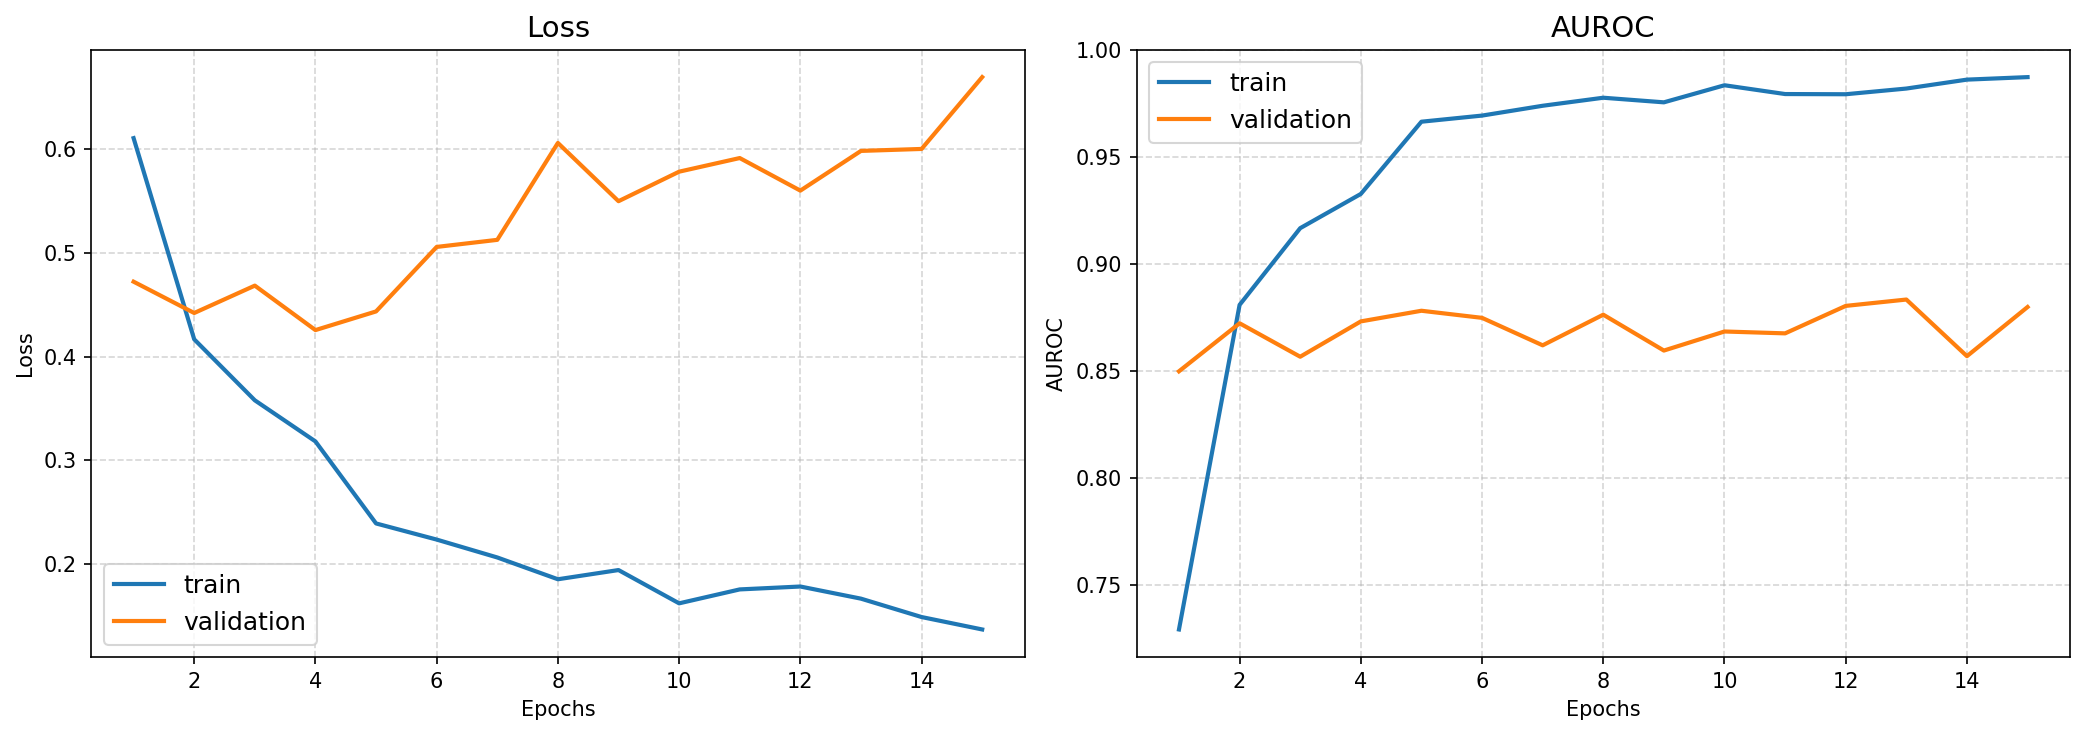

Inference: 100%|██████████| 15/15 [00:01<00:00,  8.34it/s]


추론 완료! submission_Resnet.csv 파일이 생성되었습니다.


In [8]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from tqdm import tqdm

# [추가] AUROC 계산을 위한 라이브러리 임포트
from sklearn.metrics import roc_auc_score 
import numpy as np

# 에포크 수 변경 (원하는 만큼 설정하세요. 예: 그래프처럼 보려면 100)
EPOCHS = 15  
LEARNING_RATE = 1e-4

# ==========================================
# 4. 모델 설계 (ResNet18)
# ==========================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1) 
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- [수정] 평가지표 기록을 위한 딕셔너리 선언 ---
history = {
    'train_loss': [],
    'val_loss': [],
    'train_auroc': [],
    'val_auroc': []
}

# ==========================================
# 5. 모델 학습 및 검증 루프
# ==========================================
print(f"[{DEVICE}] 환경에서 학습을 시작합니다...")

for epoch in range(EPOCHS):
    # --- [TRAINING] ---
    model.train()
    running_loss = 0.0
    
    # [추가] Train AUROC 기록용 리스트
    train_preds = []
    train_targets = []
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        
        optimizer.zero_grad()
        outputs = model(images).squeeze() 
        
        # 만약 배치 사이즈가 1인 경우 스퀴즈로 인해 차원이 날아가는 것을 방지하기 위한 안전장치
        if outputs.ndim == 0:
            outputs = outputs.unsqueeze(0)
            
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # [추가] Train 예측 확률값 및 정답 수집
        with torch.no_grad():
            probs = torch.sigmoid(outputs)
            train_preds.extend(probs.cpu().view(-1).numpy())
            train_targets.extend(labels.cpu().view(-1).numpy())
        
    epoch_train_loss = running_loss / len(train_loader)
    
    # [추가] Train AUROC 계산 (클래스 불균형 등으로 인한 에러 방지용 try-except)
    try:
        epoch_train_auroc = roc_auc_score(train_targets, train_preds)
    except ValueError:
        epoch_train_auroc = 0.5

    # --- [VALIDATION] 검증 루프 ---
    model.eval()
    val_running_loss = 0.0
    
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            outputs = model(images).squeeze()
            
            if outputs.ndim == 0:
                outputs = outputs.unsqueeze(0)
                
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            
            # [추가] Val 예측 확률값 및 정답 수집
            probs = torch.sigmoid(outputs)
            val_preds.extend(probs.cpu().view(-1).numpy())
            val_targets.extend(labels.cpu().view(-1).numpy())
            
    epoch_val_loss = val_running_loss / len(val_loader)
    
    # [추가] Val AUROC 계산
    try:
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
    except ValueError:
        epoch_val_auroc = 0.5
        
    # --- [수정] 딕셔너리에 결과 저장 ---
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_auroc'].append(epoch_train_auroc)
    history['val_auroc'].append(epoch_val_auroc)
        
    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f}")

# --- [수정] 최종 Loss 및 AUROC 그래프 시각화 (2칸으로 나누어 출력) ---
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5), dpi=150)

# 왼쪽: Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='train', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='validation', linewidth=2)
plt.title('Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 오른쪽: AUROC 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_auroc'], label='train', linewidth=2)
plt.plot(epochs_range, history['val_auroc'], label='validation', linewidth=2)
plt.title('AUROC', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('AUROC')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# 그래프 이미지 저장
plt.savefig('resnet_learning_curves.png', bbox_inches='tight')
plt.show()

# ==========================================
# 6. 테스트 추론 및 제출 파일(Submission) 생성
# ==========================================
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
predictions = []
img_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        logits = model(images).squeeze()
        
        if logits.ndim == 0:
            logits = logits.unsqueeze(0)
            
        probs = torch.sigmoid(logits).cpu().numpy()
        
        if probs.ndim == 0:
            probs = [probs.item()]
            
        predictions.extend(probs)
        img_ids.extend(ids)

submission = pd.DataFrame({
    'id': img_ids,
    'dusty_prob': predictions
})

submission.to_csv(os.path.join(path, 'submission_Resnet.csv'), index=False)
print("추론 완료! submission_Resnet.csv 파일이 생성되었습니다.")

## 1. 모델 변경 (ResNet18 ➡️ EfficientNet-B0 or B1)

- ResNet은 좋은 모델이지만 다소 무겁습니다. 파라미터 수가 적으면서도 특징 추출 능력이 극대화된 EfficientNet 계열이 소규모 데이터 전이학습(Transfer Learning)에서 훨씬 강력한 성능을 냅니다.

## 2. 최신 Optimizer와 Scheduler 도입 (AdamW + CosineAnnealingLR)

- 단순 Adam 대신 가중치 감소(Weight Decay)를 더 잘 처리하는 AdamW를 사용합니다.

- 여기에 학습률을 코사인 곡선 형태로 부드럽게 줄였다가 튕겨주는 CosineAnnealingLR 스케줄러를 달아주면, 적은 데이터에서도 모델이 Local Minima(지역 최적점)에 빠지지 않고 더 좋은 가중치를 찾아냅니다.

## 3. Mixup (믹스업) 데이터 증강 도입

- 단순히 이미지를 자르고 돌리는 것을 넘어, 두 개의 이미지와 라벨을 일정 비율로 섞어버리는(투명도를 주어 겹치는) SOTA 기법입니다. 모델이 0 아니면 1이라는 극단적인 확신을 갖는 것을 방지하여 과적합을 매우 효과적으로 막아줍니다.

In [23]:
import numpy as np
import copy  # 최적의 모델 가중치를 복사하기 위해 필요
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# [추가] AUROC 계산을 위한 라이브러리 임포트
from sklearn.metrics import roc_auc_score 

# ==========================================
# [추가] Mixup 함수 정의 (학습 루프 밖이나 위에 배치)
# ==========================================
def mixup_data(x, y, alpha=0.2, device='cuda'):
    """두 개의 배치 데이터를 섞는 Mixup 함수"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Mixup용 손실 함수 계산"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ==========================================
# 4. 모델 설계 (EfficientNet-B0) 및 하이퍼파라미터
# ==========================================
EPOCHS = 50 

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 1)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ==========================================
# [추가] Early Stopping 및 Best Model 저장을 위한 변수 초기화
# ==========================================
patience = 7                  # 검증 손실이 개선되지 않을 때 참아줄 최대 에폭 수
counter = 0                   # 개선되지 않은 에폭을 세는 카운터
best_val_loss = float('inf')  # 가장 낮은 검증 손실을 기억하기 위한 변수
best_model_wts = copy.deepcopy(model.state_dict())  # 최적의 모델 가중치 저장소

# ==========================================
# 5. 모델 학습 및 검증 루프 (Mixup + Early Stopping + AUROC)
# ==========================================
print(f"[{DEVICE}] 환경에서 학습을 시작합니다...")
for epoch in range(EPOCHS):
    
    # ---------- 1. Train Phase ----------
    model.train()
    running_train_loss = 0.0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train"):
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        
        # Mixup 적용
        inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(-1) # 1차원으로 맞춤
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    scheduler.step()
    epoch_train_loss = running_train_loss / len(train_loader)
    
    # ---------- 2. Validation Phase ----------
    model.eval()
    running_val_loss = 0.0
    
    # [추가] AUROC 계산을 위해 예측값과 실제 정답을 저장할 리스트
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            outputs = model(images).squeeze(-1)
            
            # 검증 데이터는 Mixup을 하지 않고 원본 상태로 손실을 계산합니다.
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            # [추가] BCEWithLogitsLoss를 사용하므로 예측값을 0~1 사이의 확률로 변환 (Sigmoid)
            probs = torch.sigmoid(outputs)
            
            # [추가] 계산을 위해 리스트에 누적 (.view(-1)로 차원 문제를 방지)
            val_preds.extend(probs.cpu().view(-1).numpy())
            val_targets.extend(labels.cpu().view(-1).numpy())
            
    epoch_val_loss = running_val_loss / len(val_loader)
    
    # [추가] 사이킷런을 이용해 AUROC 스코어 계산
    epoch_val_auroc = roc_auc_score(val_targets, val_preds)
    current_lr = scheduler.get_last_lr()[0]
    
    # [수정] Print문에 Val AUROC 점수 추가
    print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val AUROC: {epoch_val_auroc:.4f} | LR: {current_lr:.6f}")
    
    # ---------- 3. Early Stopping Check ----------
    # (주의: Early stopping은 loss 기준으로 유지합니다. 만약 auroc 기준으로 하려면 부등호를 반대로 변경해야 합니다.)
    if epoch_val_loss < best_val_loss:
        print(f"  ▶ Val Loss가 개선되었습니다! ({best_val_loss:.4f} ➡️ {epoch_val_loss:.4f}). 모델 가중치를 저장합니다.")
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적의 모델 상태 기억
        counter = 0 # 카운터 리셋
    else:
        counter += 1
        print(f"  ▶ Val Loss가 개선되지 않았습니다. (Early Stopping Counter: {counter}/{patience})")
        
        if counter >= patience:
            print(f"⚠️ {patience} 에폭 동안 성능 개선이 없어 조기 종료(Early Stopping)를 수행합니다.")
            break

# ---------- 4. 최적의 모델 복원 ----------
model.load_state_dict(best_model_wts)
print("🏆 최적의 가중치 복원 완료! 이 모델로 테스트 추론을 진행합니다.")


# ==========================================
# 6. 테스트 추론 및 제출 파일(Submission) 생성
# ==========================================
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
predictions = []
img_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        logits = model(images).squeeze(-1)
        
        # Sigmoid를 통과시켜 0~1 사이의 확률(dusty_prob)로 변환
        probs = torch.sigmoid(logits).cpu().numpy()
        
        # Batch size가 1일 경우 배열 처리를 위한 예외 처리
        if probs.ndim == 0:
            probs = [probs.item()]
            
        predictions.extend(probs)
        img_ids.extend(ids)

# 결과 저장
submission = pd.DataFrame({
    'id': img_ids,
    'dusty_prob': predictions
})

submission.to_csv(os.path.join(path, 'submission_efficient2.csv'), index=False)
print("추론 완료! submission_efficient.csv 파일이 생성되었습니다.")

[cuda] 환경에서 학습을 시작합니다...


Epoch 1/50 Train: 100%|██████████| 28/28 [00:05<00:00,  4.73it/s]


Epoch 1 - Train Loss: 0.6536 | Val Loss: 0.5693 | Val AUROC: 0.8230 | LR: 0.000100
  ▶ Val Loss가 개선되었습니다! (inf ➡️ 0.5693). 모델 가중치를 저장합니다.


Epoch 2/50 Train: 100%|██████████| 28/28 [00:05<00:00,  5.22it/s]


Epoch 2 - Train Loss: 0.5925 | Val Loss: 0.5097 | Val AUROC: 0.8614 | LR: 0.000100
  ▶ Val Loss가 개선되었습니다! (0.5693 ➡️ 0.5097). 모델 가중치를 저장합니다.


...

Epoch 14 - Train Loss: 0.3078 | Val Loss: 0.4028 | Val AUROC: 0.8950 | LR: 0.000082
  ▶ Val Loss가 개선되지 않았습니다. (Early Stopping Counter: 6/7)


Epoch 15/50 Train: 100%|██████████| 28/28 [00:05<00:00,  5.03it/s]


Epoch 15 - Train Loss: 0.2980 | Val Loss: 0.4242 | Val AUROC: 0.8813 | LR: 0.000080
  ▶ Val Loss가 개선되지 않았습니다. (Early Stopping Counter: 7/7)
⚠️ 7 에폭 동안 성능 개선이 없어 조기 종료(Early Stopping)를 수행합니다.
🏆 최적의 가중치 복원 완료! 이 모델로 테스트 추론을 진행합니다.


Inference: 100%|██████████| 15/15 [00:01<00:00,  8.42it/s]

추론 완료! submission_efficient.csv 파일이 생성되었습니다.


[cuda] 환경에서 학습을 시작합니다...


Epoch 1/50 Train: 100%|██████████| 28/28 [00:05<00:00,  4.82it/s]


Epoch 1 - Train Loss: 0.6632 | Val Loss: 0.5883 | Train AUROC: 0.5215 | Val AUROC: 0.7828 | LR: 0.000100
  ▶ Val Loss가 개선되었습니다! (inf ➡️ 0.5883). 모델 가중치를 저장합니다.


Epoch 2/50 Train: 100%|██████████| 28/28 [00:05<00:00,  5.04it/s]


Epoch 2 - Train Loss: 0.5786 | Val Loss: 0.5173 | Train AUROC: 0.6320 | Val AUROC: 0.8421 | LR: 0.000100
  ▶ Val Loss가 개선되었습니다! (0.5883 ➡️ 0.5173). 모델 가중치를 저장합니다.


...

Epoch 12 - Train Loss: 0.3032 | Val Loss: 0.4361 | Train AUROC: 0.8235 | Val AUROC: 0.8705 | LR: 0.000087
  ▶ Val Loss가 개선되지 않았습니다. (Early Stopping Counter: 5/7)


Epoch 13/50 Train: 100%|██████████| 28/28 [00:05<00:00,  4.92it/s]


Epoch 13 - Train Loss: 0.3054 | Val Loss: 0.4408 | Train AUROC: 0.6190 | Val AUROC: 0.8700 | LR: 0.000084
  ▶ Val Loss가 개선되지 않았습니다. (Early Stopping Counter: 6/7)


Epoch 14/50 Train: 100%|██████████| 28/28 [00:05<00:00,  4.92it/s]


Epoch 14 - Train Loss: 0.3450 | Val Loss: 0.4565 | Train AUROC: 0.7294 | Val AUROC: 0.8553 | LR: 0.000082
  ▶ Val Loss가 개선되지 않았습니다. (Early Stopping Counter: 7/7)
⚠️ 7 에폭 동안 성능 개선이 없어 조기 종료(Early Stopping)를 수행합니다.
🏆 최적의 가중치 복원 완료! 이 모델로 테스트 추론을 진행합니다.


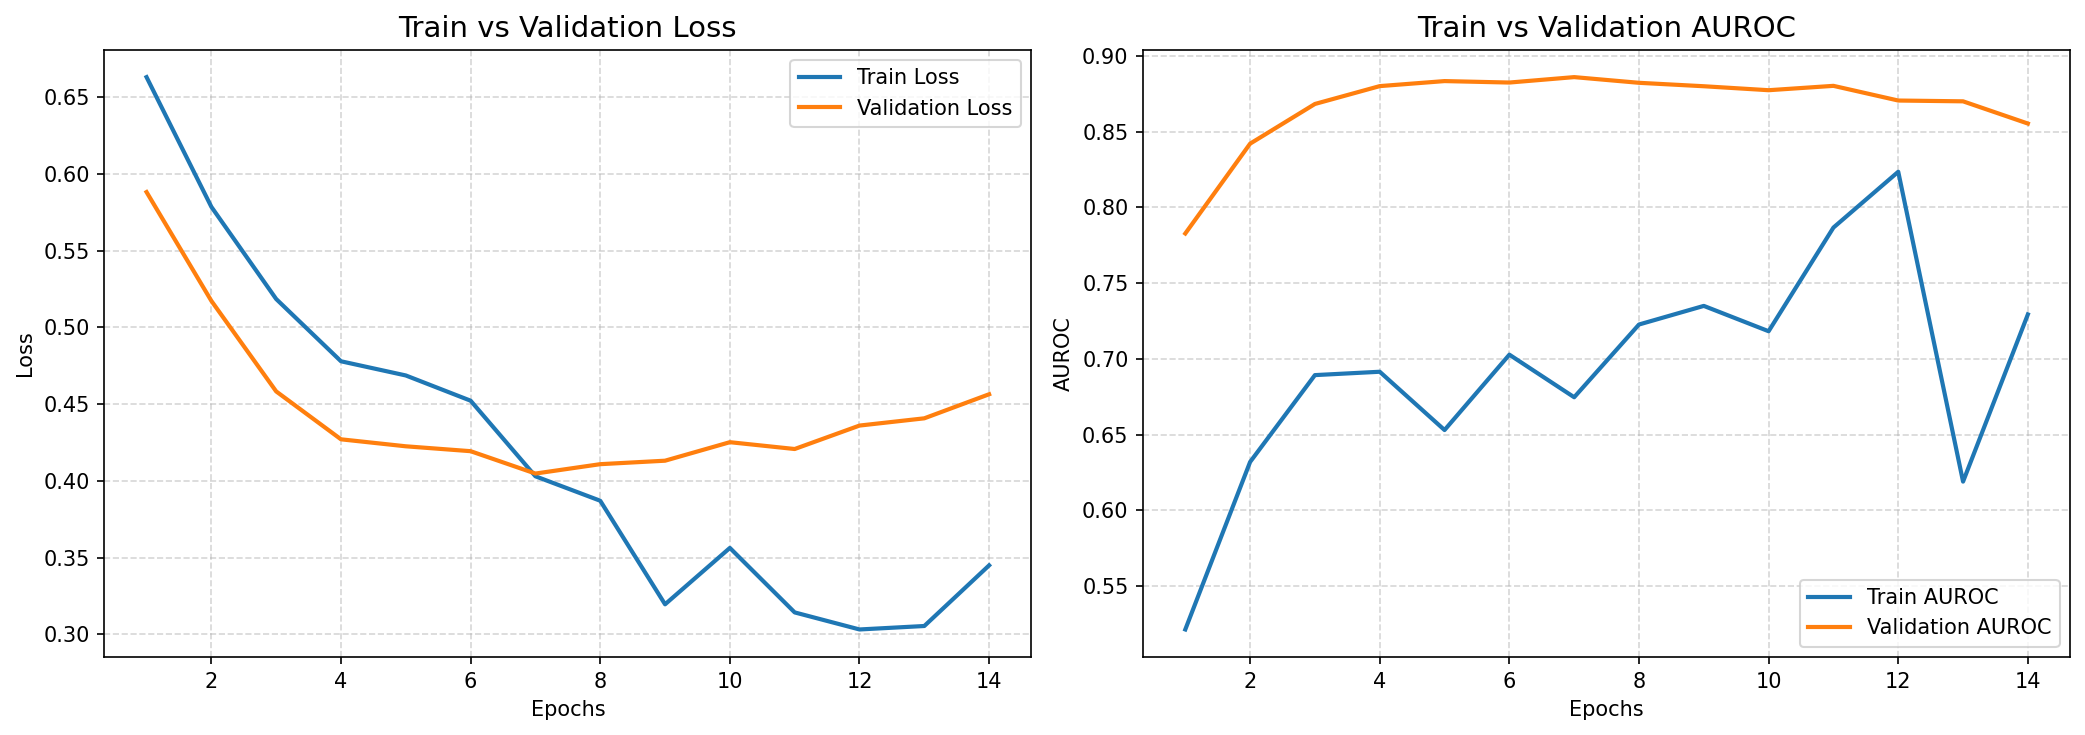

Inference: 100%|██████████| 15/15 [00:01<00:00,  8.44it/s]


추론 완료! submission_efficient2.csv 파일이 생성되었습니다.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import copy  # 최적의 모델 가중치를 복사하기 위해 필요
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# [추가] AUROC 계산을 위한 라이브러리 임포트
from sklearn.metrics import roc_auc_score 

# ==========================================
# [추가] Mixup 함수 정의 (학습 루프 밖이나 위에 배치)
# ==========================================
def mixup_data(x, y, alpha=0.2, device='cuda'):
    """두 개의 배치 데이터를 섞는 Mixup 함수"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Mixup용 손실 함수 계산"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ==========================================
# 4. 모델 설계 (EfficientNet-B0) 및 하이퍼파라미터
# ==========================================
EPOCHS = 50 

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 1)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ==========================================
# [추가] Early Stopping 및 Best Model 저장을 위한 변수 초기화
# ==========================================
patience = 7                  # 검증 손실이 개선되지 않을 때 참아줄 최대 에폭 수
counter = 0                   # 개선되지 않은 에폭을 세는 카운터
best_val_loss = float('inf')  # 가장 낮은 검증 손실을 기억하기 위한 변수
best_model_wts = copy.deepcopy(model.state_dict())  # 최적의 모델 가중치 저장소

# --- [수정] 그래프 시각화를 위한 기록용 리스트 선언 ---
history = {
    'train_loss': [],
    'val_loss': [],
    'train_auroc': [],
    'val_auroc': []
}

# ==========================================
# 5. 모델 학습 및 검증 루프 (Mixup + Early Stopping + AUROC)
# ==========================================
print(f"[{DEVICE}] 환경에서 학습을 시작합니다...")
for epoch in range(EPOCHS):
    
    # ---------- 1. Train Phase ----------
    model.train()
    running_train_loss = 0.0
    
    # Train AUROC 측정을 위한 리스트
    train_preds = []
    train_targets = []
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train"):
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        
        # Mixup 적용
        inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(-1) # 1차원으로 맞춤
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        # [추가] Train AUROC 기록용 (Mixup 데이터가 아닌 원본 레이블 기준으로 평가)
        with torch.no_grad():
            # Mixup이 들어가지 않은 순수 모델의 예측을 보기 위해 
            # 혹은 Mixup 상태의 가중치로 원본 이미지를 다시 추론하는 대신 효율성을 위해 outputs를 활용합니다.
            probs = torch.sigmoid(outputs)
            train_preds.extend(probs.cpu().view(-1).numpy())
            # Mixup 타겟 분할 비율을 반영하여 실제 정답에 가까운 대푯값 저장
            # (또는 단순 레이블 추적을 원하시면 그냥 labels를 기록해도 무방하나 Mixup 손실 특성상 아래가 합리적입니다)
            train_targets.extend((lam * labels + (1 - lam) * labels[torch.randperm(labels.size()[0]).to(DEVICE)]).cpu().view(-1).numpy())
        
    scheduler.step()
    epoch_train_loss = running_train_loss / len(train_loader)
    
    # 스코어 변환 에러를 방지하기 위해 이진 분류 threshold 형식 혹은 반올림 처리 조율 가능하나 일반적으로 소수점 타겟도 roc_auc_score가 지원합니다.
    # 만약 에러가 발생한다면 train_targets 수집 시 믹스업 전의 순수 labels를 기록하시면 됩니다.
    try:
        epoch_train_auroc = roc_auc_score((np.array(train_targets) > 0.5).astype(int), train_preds)
    except:
        epoch_train_auroc = 0.5 # 클래스가 하나만 잡히는 배치가 있을 경우 예외 처리
    
    # ---------- 2. Validation Phase ----------
    model.eval()
    running_val_loss = 0.0
    
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            outputs = model(images).squeeze(-1)
            
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            probs = torch.sigmoid(outputs)
            
            val_preds.extend(probs.cpu().view(-1).numpy())
            val_targets.extend(labels.cpu().view(-1).numpy())
            
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_auroc = roc_auc_score(val_targets, val_preds)
    
    current_lr = scheduler.get_last_lr()[0]
    
    # --- [수정] 히스토리에 수치들 저장 ---
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_auroc'].append(epoch_train_auroc)
    history['val_auroc'].append(epoch_val_auroc)
    
    # Print문에 Train 정보도 추가
    print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f} | LR: {current_lr:.6f}")
    
    # ---------- 3. Early Stopping Check ----------
    if epoch_val_loss < best_val_loss:
        print(f"  ▶ Val Loss가 개선되었습니다! ({best_val_loss:.4f} ➡️ {epoch_val_loss:.4f}). 모델 가중치를 저장합니다.")
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) 
        counter = 0 
    else:
        counter += 1
        print(f"  ▶ Val Loss가 개선되지 않았습니다. (Early Stopping Counter: {counter}/{patience})")
        
        if counter >= patience:
            print(f"⚠️ {patience} 에폭 동안 성능 개선이 없어 조기 종료(Early Stopping)를 수행합니다.")
            break

# ---------- 4. 최적의 모델 복원 ----------
model.load_state_dict(best_model_wts)
print("🏆 최적의 가중치 복원 완료! 이 모델로 테스트 추론을 진행합니다.")


# --- [추가] 최종 Train/Val Loss 및 AUROC 그래프 시각화 ---
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5), dpi=150)

# 1. Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Train vs Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. AUROC 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_auroc'], label='Train AUROC', linewidth=2)
plt.plot(epochs_range, history['val_auroc'], label='Validation AUROC', linewidth=2)
plt.title('Train vs Validation AUROC', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('AUROC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight')
plt.show()


# ==========================================
# 6. 테스트 추론 및 제출 파일(Submission) 생성
# ==========================================
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
predictions = []
img_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        logits = model(images).squeeze(-1)
        
        probs = torch.sigmoid(logits).cpu().numpy()
        
        if probs.ndim == 0:
            probs = [probs.item()]
            
        predictions.extend(probs)
        img_ids.extend(ids)

# 결과 저장
submission = pd.DataFrame({
    'id': img_ids,
    'dusty_prob': predictions
})

submission.to_csv(os.path.join(path, 'submission_efficient_plot.csv'), index=False)
print("추론 완료! submission_efficient2.csv 파일이 생성되었습니다.")

## 전략 A: 전체 데이터 학습 (Full Data Training)
- 검증 데이터로 낭비되는 20% 없이 100% 데이터를 모두 학습에 쏟아붓는 방법입니다. 이전 실험에서 10 Epoch 부근이 최적이라는 것을 알았으므로, 과감하게 Early Stopping을 빼고 딱 12 Epoch만 돌린 후 바로 추론합니다.

[cuda] 전략 A: 학습을 시작합니다...


Epoch 1/15 Train: 100%|██████████| 23/23 [00:04<00:00,  5.06it/s]


Epoch 1 - Train Loss: 0.6610 | Val Loss: 0.6064 | Train AUROC: 0.5605 | Val AUROC: 0.7264 | LR: 0.000099


Epoch 2/15 Train: 100%|██████████| 23/23 [00:04<00:00,  5.17it/s]


Epoch 2 - Train Loss: 0.5981 | Val Loss: 0.5505 | Train AUROC: 0.6051 | Val AUROC: 0.8016 | LR: 0.000096


...

Epoch 13 - Train Loss: 0.3733 | Val Loss: 0.4418 | Train AUROC: 0.7382 | Val AUROC: 0.8637 | LR: 0.000005


Epoch 14/15 Train: 100%|██████████| 23/23 [00:04<00:00,  5.31it/s]


Epoch 14 - Train Loss: 0.3416 | Val Loss: 0.4424 | Train AUROC: 0.7093 | Val AUROC: 0.8585 | LR: 0.000002


Epoch 15/15 Train: 100%|██████████| 23/23 [00:04<00:00,  5.13it/s]


Epoch 15 - Train Loss: 0.3207 | Val Loss: 0.4410 | Train AUROC: 0.7568 | Val AUROC: 0.8584 | LR: 0.000001
🏆 15 Epoch 학습 및 검증 완료! 시각화를 진행합니다.


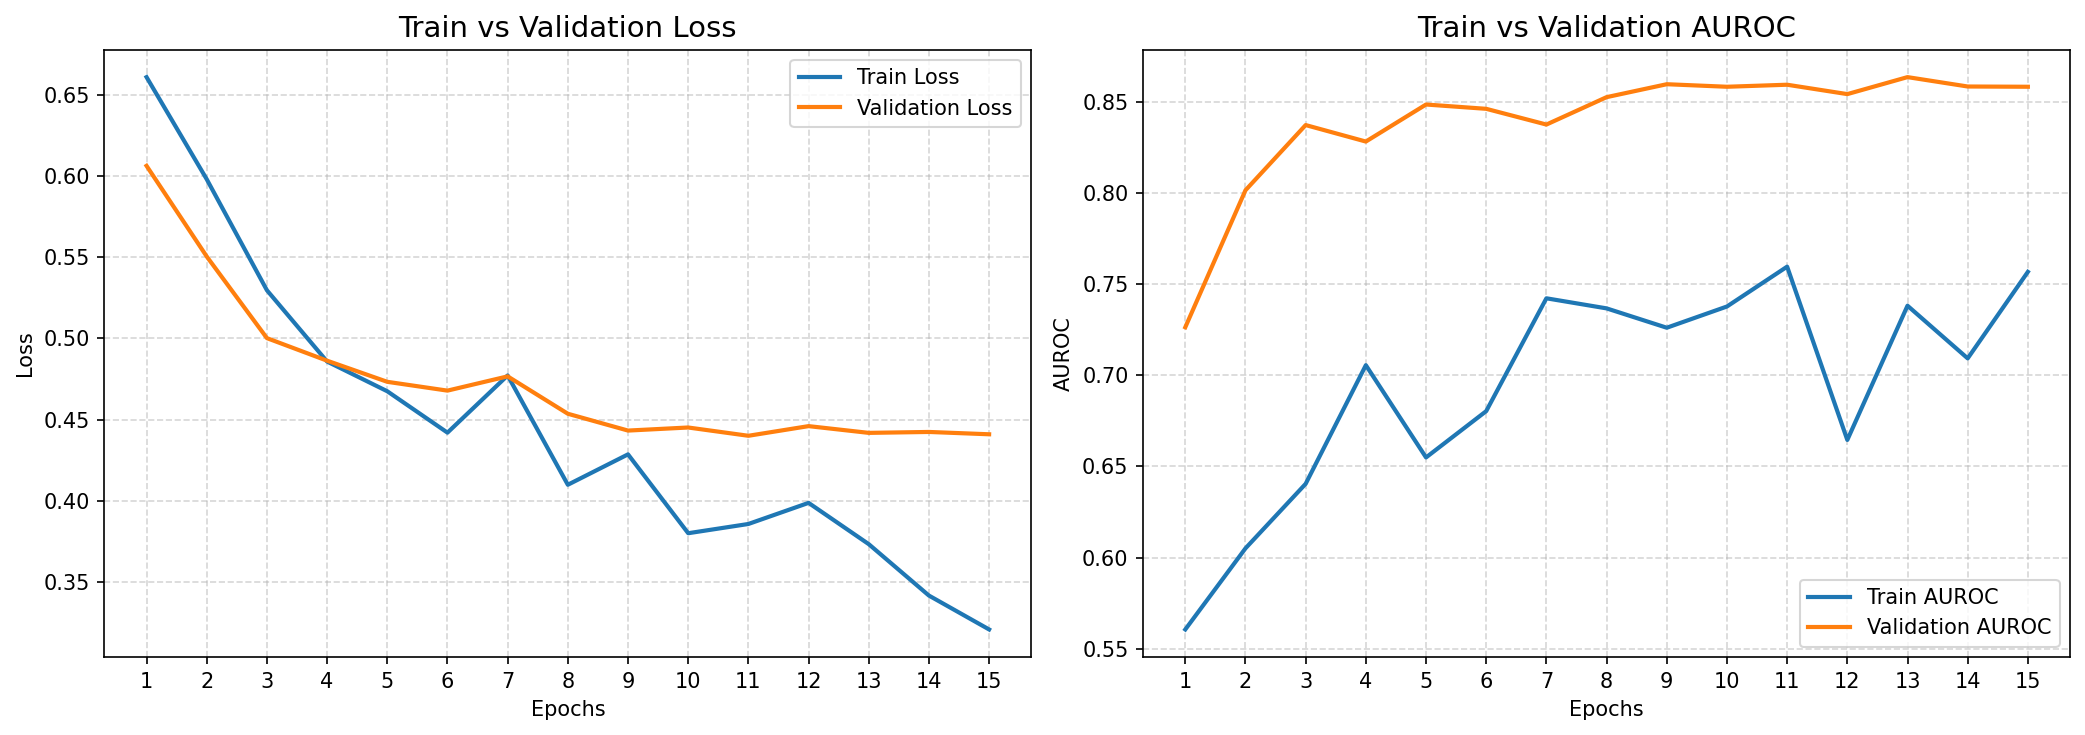

Inference: 100%|██████████| 15/15 [00:01<00:00,  8.13it/s]

추론 완료! submission_strategy_A2.csv 생성됨.


In [10]:

# ==========================================
# 전략 A: 데이터 분할 및 학습 (Loss & AUROC 시각화 추가)
# ==========================================
print(f"[{DEVICE}] 전략 A: 학습을 시작합니다...")

# [수정] Validation 측정을 위해 전체 train_df를 8:2 비율로 분할합니다.
# 데이터 프레임 구조에 맞게 stratify 기준(예: 'label' 혹은 'dusty')을 지정하면 더 좋습니다.
# 여기서는 일반적인 분할 방식을 적용했습니다.
train_split_df, val_split_df = train_test_split(train_df, test_size=0.2, random_state=42)

# DataLoader 구성
train_dataset = SolarPanelDataset(train_split_df, train_img_dir, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = SolarPanelDataset(val_split_df, train_img_dir, transform=test_transform) # 검증에는 test_transform 권장
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. 모델 및 하이퍼파라미터
EPOCHS = 15
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# --- [추가] 지표 기록을 위한 히스토리 딕셔너리 ---
history = {
    'train_loss': [],
    'val_loss': [],
    'train_auroc': [],
    'val_auroc': []
}

# 3. 모델 학습 및 검증 루프
for epoch in range(EPOCHS):
    # ---------- 1. Train Phase ----------
    model.train()
    running_train_loss = 0.0
    
    train_preds = []
    train_targets = []
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train"):
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        
        # Mixup 적용
        inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(-1)
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        
        # Train AUROC 기록을 위해 예측 확률과 타겟 수집
        with torch.no_grad():
            probs = torch.sigmoid(outputs)
            train_preds.extend(probs.cpu().view(-1).numpy())
            # Mixup이 반영된 소프트 타겟 생성 (에러 방지를 위해 이후 0.5 기준으로 이진화)
            mix_target = lam * labels + (1 - lam) * labels[torch.randperm(labels.size()[0]).to(DEVICE)]
            train_targets.extend(mix_target.cpu().view(-1).numpy())
            
    scheduler.step()
    epoch_train_loss = running_train_loss / len(train_loader)
    
    # Train AUROC 계산 (에러 방지 안전장치 포함)
    try:
        epoch_train_auroc = roc_auc_score((np.array(train_targets) > 0.5).astype(int), train_preds)
    except ValueError:
        epoch_train_auroc = 0.5

    # ---------- 2. Validation Phase ----------
    model.eval()
    running_val_loss = 0.0
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            outputs = model(images).squeeze(-1)
            
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            probs = torch.sigmoid(outputs)
            val_preds.extend(probs.cpu().view(-1).numpy())
            val_targets.extend(labels.cpu().view(-1).numpy())
            
    epoch_val_loss = running_val_loss / len(val_loader)
    
    try:
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
    except ValueError:
        epoch_val_auroc = 0.5
        
    current_lr = scheduler.get_last_lr()[0]
    
    # --- [추가] 히스토리에 수치 기록 ---
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_auroc'].append(epoch_train_auroc)
    history['val_auroc'].append(epoch_val_auroc)
    
    print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f} | LR: {current_lr:.6f}")

print(f"🏆 {EPOCHS} Epoch 학습 및 검증 완료! 시각화를 진행합니다.")

# --- [추가] 최종 Train/Val Loss 및 AUROC 그래프 시각화 ---
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5), dpi=150)

# 왼쪽: Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Train vs Validation Loss', fontsize=14)
# x축 눈금을 정수로 표현하기 위함
plt.xticks(epochs_range)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 오른쪽: AUROC 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_auroc'], label='Train AUROC', linewidth=2)
plt.plot(epochs_range, history['val_auroc'], label='Validation AUROC', linewidth=2)
plt.title('Train vs Validation AUROC', fontsize=14)
plt.xticks(epochs_range)
plt.xlabel('Epochs')
plt.ylabel('AUROC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('strategy_a_learning_curves.png', bbox_inches='tight')
plt.show()

# 4. 테스트 추론
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
predictions, img_ids = [], []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        logits = model(images).squeeze(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        if probs.ndim == 0: probs = [probs.item()]
        predictions.extend(probs)
        img_ids.extend(ids)

pd.DataFrame({'id': img_ids, 'dusty_prob': predictions}).to_csv(os.path.join(path, 'submission_strategy_A2.csv'), index=False)
print("추론 완료! submission_strategy_A2.csv 생성됨.")

## 전략 B: 5-Fold 교차 검증 앙상블 (K-Fold Ensemble)
시간은 5배 걸리지만, 데이터가 적을 때 나타나는 '검증 데이터 불일치' 문제를 완벽히 해결하는 방법입니다. 5개의 각기 다른 모델이 예측한 확률을 평균(Mean) 내어 제출합니다.

In [25]:
# ==========================================
# 전략 B: 5-Fold 앙상블 (Mixup O, Val Loss Early Stopping)
# ==========================================
from sklearn.model_selection import StratifiedKFold

K_FOLDS = 5
EPOCHS = 50
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['label'].values 

# 테스트 데이터 로더 준비
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_preds_ensemble = np.zeros(len(test_dataset))

print(f"[{DEVICE}] 전략 B: 5-Fold 교차 검증 앙상블을 시작합니다...")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, all_labels)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    train_loader = DataLoader(SolarPanelDataset(fold_train_df, train_img_dir, transform=train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SolarPanelDataset(fold_val_df, train_img_dir, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False)
    
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    patience, counter = 7, 0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        scheduler.step()
        
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images).squeeze(-1)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
                val_targets.extend(labels.cpu().view(-1).numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
        print(f"Epoch {epoch+1} - Val Loss: {epoch_val_loss:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("⚠️ Early Stopping 발동")
                break
                
    # Fold 추론
    model.load_state_dict(best_model_wts)
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
            if probs.ndim == 0: probs = [probs.item()]
            fold_preds.extend(probs)
    test_preds_ensemble += np.array(fold_preds)

test_preds_ensemble /= K_FOLDS
pd.DataFrame({'id': sub_df['id'], 'dusty_prob': test_preds_ensemble}).to_csv(os.path.join(path, 'submission_strategy_B2.csv'), index=False)
print("추론 완료! submission_strategy_B.csv 생성됨.")

[cuda] 전략 B: 5-Fold 교차 검증 앙상블을 시작합니다...

========== Fold 1/5 ==========
Epoch 1 - Val Loss: 0.6456 | Val AUROC: 0.6818
Epoch 2 - Val Loss: 0.5688 | Val AUROC: 0.7874
Epoch 3 - Val Loss: 0.5328 | Val AUROC: 0.8233
Epoch 4 - Val Loss: 0.4929 | Val AUROC: 0.8404
Epoch 5 - Val Loss: 0.4954 | Val AUROC: 0.8392
Epoch 6 - Val Loss: 0.4862 | Val AUROC: 0.8436
Epoch 7 - Val Loss: 0.4745 | Val AUROC: 0.8520
Epoch 8 - Val Loss: 0.4820 | Val AUROC: 0.8502
Epoch 9 - Val Loss: 0.4933 | Val AUROC: 0.8457
Epoch 10 - Val Loss: 0.5005 | Val AUROC: 0.8464
Epoch 11 - Val Loss: 0.5335 | Val AUROC: 0.8446
Epoch 12 - Val Loss: 0.5600 | Val AUROC: 0.8305
Epoch 13 - Val Loss: 0.5499 | Val AUROC: 0.8242
Epoch 14 - Val Loss: 0.5656 | Val AUROC: 0.8308
⚠️ Early Stopping 발동

========== Fold 2/5 ==========
Epoch 1 - Val Loss: 0.6191 | Val AUROC: 0.7620
Epoch 2 - Val Loss: 0.5600 | Val AUROC: 0.8053
Epoch 3 - Val Loss: 0.5311 | Val AUROC: 0.8080
Epoch 4 - Val Loss: 0.4983 | Val AUROC: 0.8304
Epoch 5 - Val Loss: 0.46

[cuda] 전략 B: 5-Fold 교차 검증 앙상블을 시작합니다...

========== Fold 1/5 ==========


Epoch 1 - Train Loss: 0.6520 | Val Loss: 0.5918 | Train AUROC: 0.5300 | Val AUROC: 0.7533


Epoch 2 - Train Loss: 0.5800 | Val Loss: 0.5407 | Train AUROC: 0.6171 | Val AUROC: 0.8039


Epoch 3 - Train Loss: 0.5614 | Val Loss: 0.5178 | Train AUROC: 0.6216 | Val AUROC: 0.8225


Epoch 4 - Train Loss: 0.4671 | Val Loss: 0.4886 | Train AUROC: 0.6777 | Val AUROC: 0.8403


...

Epoch 8 - Train Loss: 0.3890 | Val Loss: 0.4901 | Train AUROC: 0.7337 | Val AUROC: 0.8472


Epoch 9 - Train Loss: 0.3410 | Val Loss: 0.4982 | Train AUROC: 0.7419 | Val AUROC: 0.8517


Epoch 10 - Train Loss: 0.4098 | Val Loss: 0.5008 | Train AUROC: 0.7093 | Val AUROC: 0.8461


Epoch 11 - Train Loss: 0.3282 | Val Loss: 0.5079 | Train AUROC: 0.7234 | Val AUROC: 0.8444


Epoch 12 - Train Loss: 0.3611 | Val Loss: 0.5252 | Train AUROC: 0.8004 | Val AUROC: 0.8366
⚠️ Fold 1 Early Stopping 발동 (최적 에포크 복원)


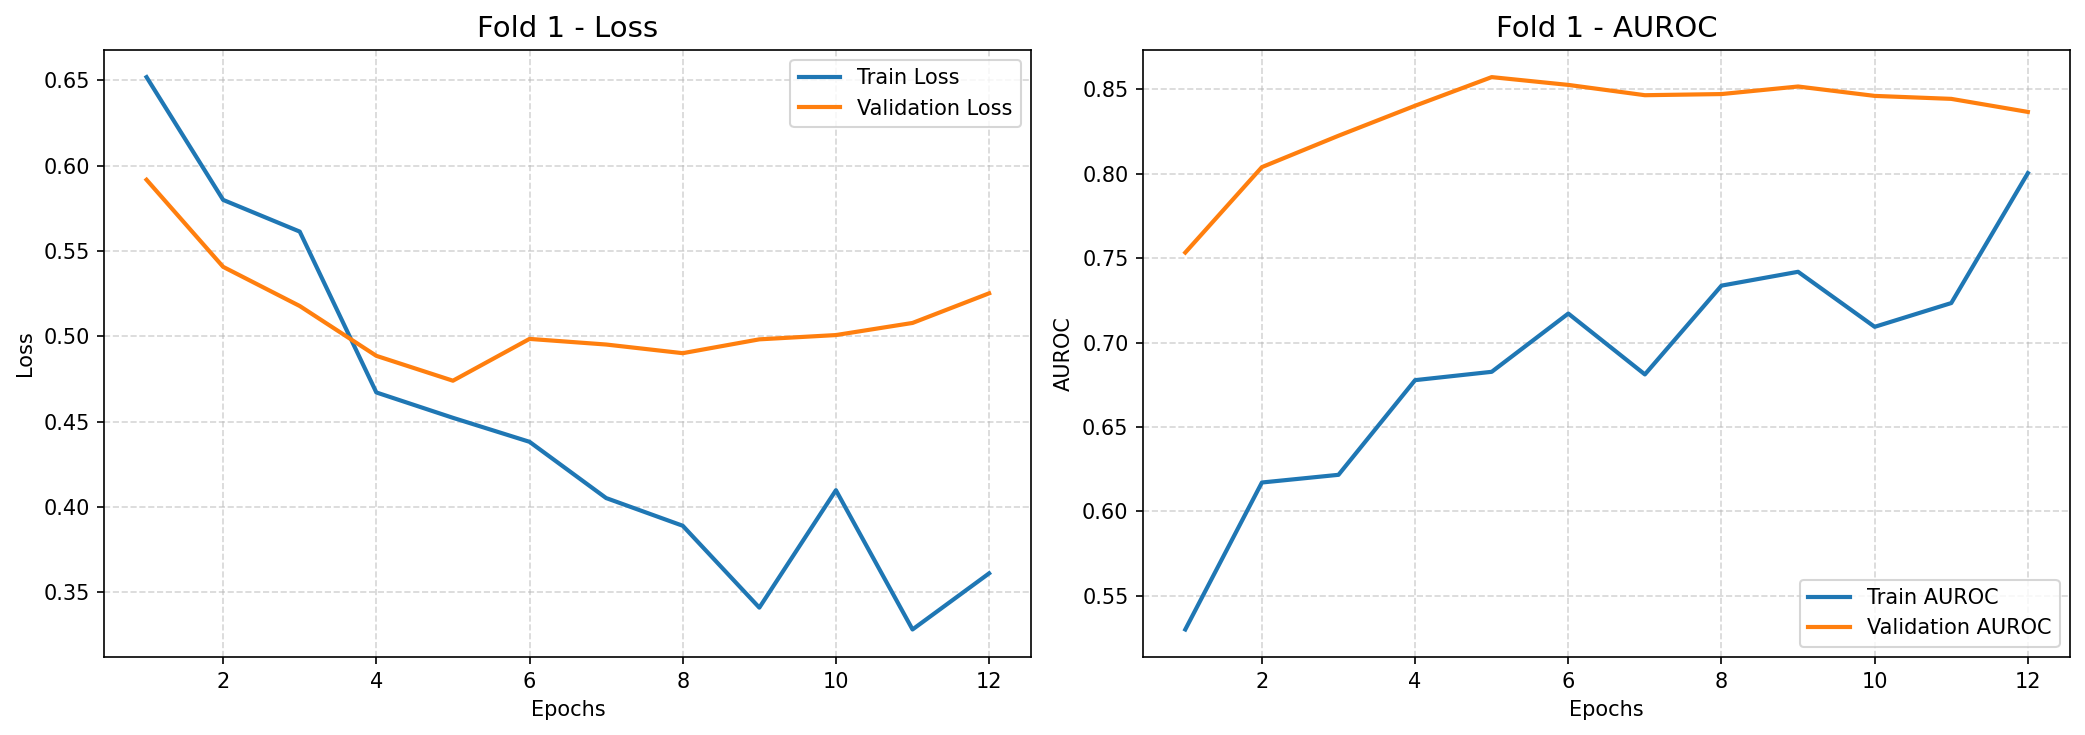


========== Fold 2/5 ==========


Epoch 1 - Train Loss: 0.6737 | Val Loss: 0.6235 | Train AUROC: 0.5634 | Val AUROC: 0.7130


Epoch 2 - Train Loss: 0.5987 | Val Loss: 0.5793 | Train AUROC: 0.6401 | Val AUROC: 0.7782


Epoch 3 - Train Loss: 0.5370 | Val Loss: 0.5507 | Train AUROC: 0.5957 | Val AUROC: 0.7830


Epoch 4 - Train Loss: 0.5107 | Val Loss: 0.5097 | Train AUROC: 0.7558 | Val AUROC: 0.8274


...

Epoch 24 - Train Loss: 0.2827 | Val Loss: 0.3779 | Train AUROC: 0.7106 | Val AUROC: 0.9061


Epoch 25 - Train Loss: 0.1971 | Val Loss: 0.3815 | Train AUROC: 0.7394 | Val AUROC: 0.9099


Epoch 26 - Train Loss: 0.2758 | Val Loss: 0.3932 | Train AUROC: 0.6876 | Val AUROC: 0.9049


Epoch 27 - Train Loss: 0.2293 | Val Loss: 0.4104 | Train AUROC: 0.7628 | Val AUROC: 0.8985


Epoch 28 - Train Loss: 0.2509 | Val Loss: 0.4041 | Train AUROC: 0.7439 | Val AUROC: 0.8974
⚠️ Fold 2 Early Stopping 발동 (최적 에포크 복원)


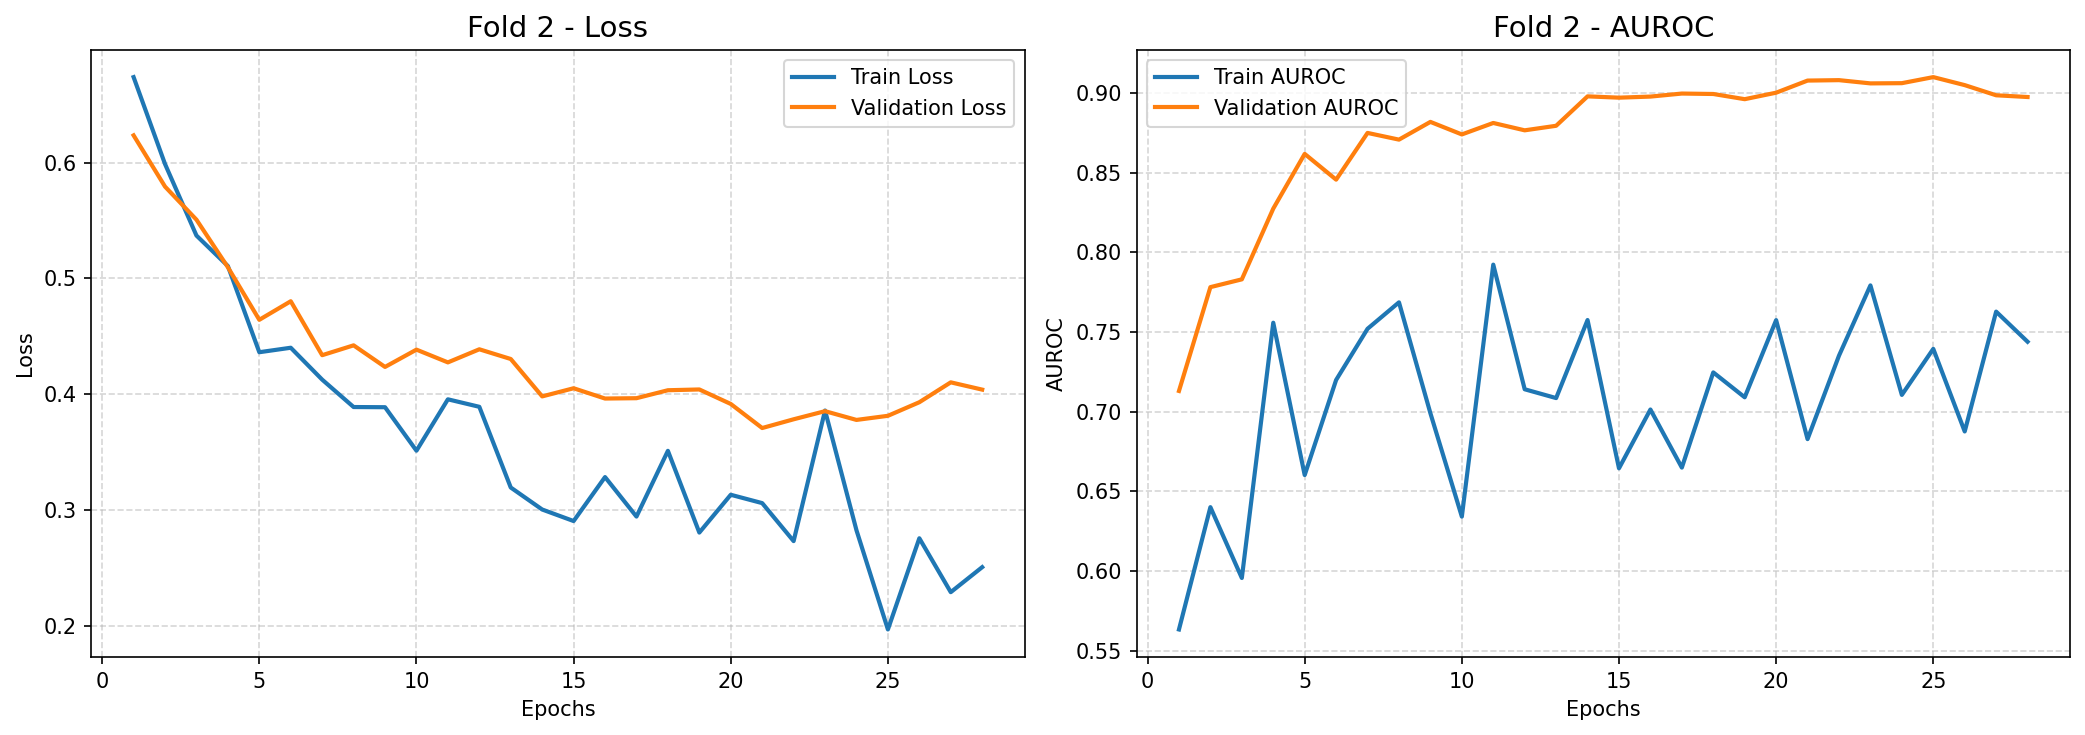


========== Fold 3/5 ==========


Epoch 1 - Train Loss: 0.6794 | Val Loss: 0.6065 | Train AUROC: 0.5153 | Val AUROC: 0.7688


Epoch 2 - Train Loss: 0.5869 | Val Loss: 0.5499 | Train AUROC: 0.5896 | Val AUROC: 0.8180


Epoch 3 - Train Loss: 0.5526 | Val Loss: 0.5126 | Train AUROC: 0.6725 | Val AUROC: 0.8246


Epoch 4 - Train Loss: 0.4948 | Val Loss: 0.5002 | Train AUROC: 0.6498 | Val AUROC: 0.8270


...

Epoch 10 - Train Loss: 0.3881 | Val Loss: 0.4297 | Train AUROC: 0.6599 | Val AUROC: 0.8689


Epoch 11 - Train Loss: 0.3836 | Val Loss: 0.4394 | Train AUROC: 0.7251 | Val AUROC: 0.8590


Epoch 12 - Train Loss: 0.3255 | Val Loss: 0.4599 | Train AUROC: 0.8144 | Val AUROC: 0.8642


Epoch 13 - Train Loss: 0.3200 | Val Loss: 0.4385 | Train AUROC: 0.7545 | Val AUROC: 0.8674


Epoch 14 - Train Loss: 0.3401 | Val Loss: 0.4622 | Train AUROC: 0.8068 | Val AUROC: 0.8733
⚠️ Fold 3 Early Stopping 발동 (최적 에포크 복원)


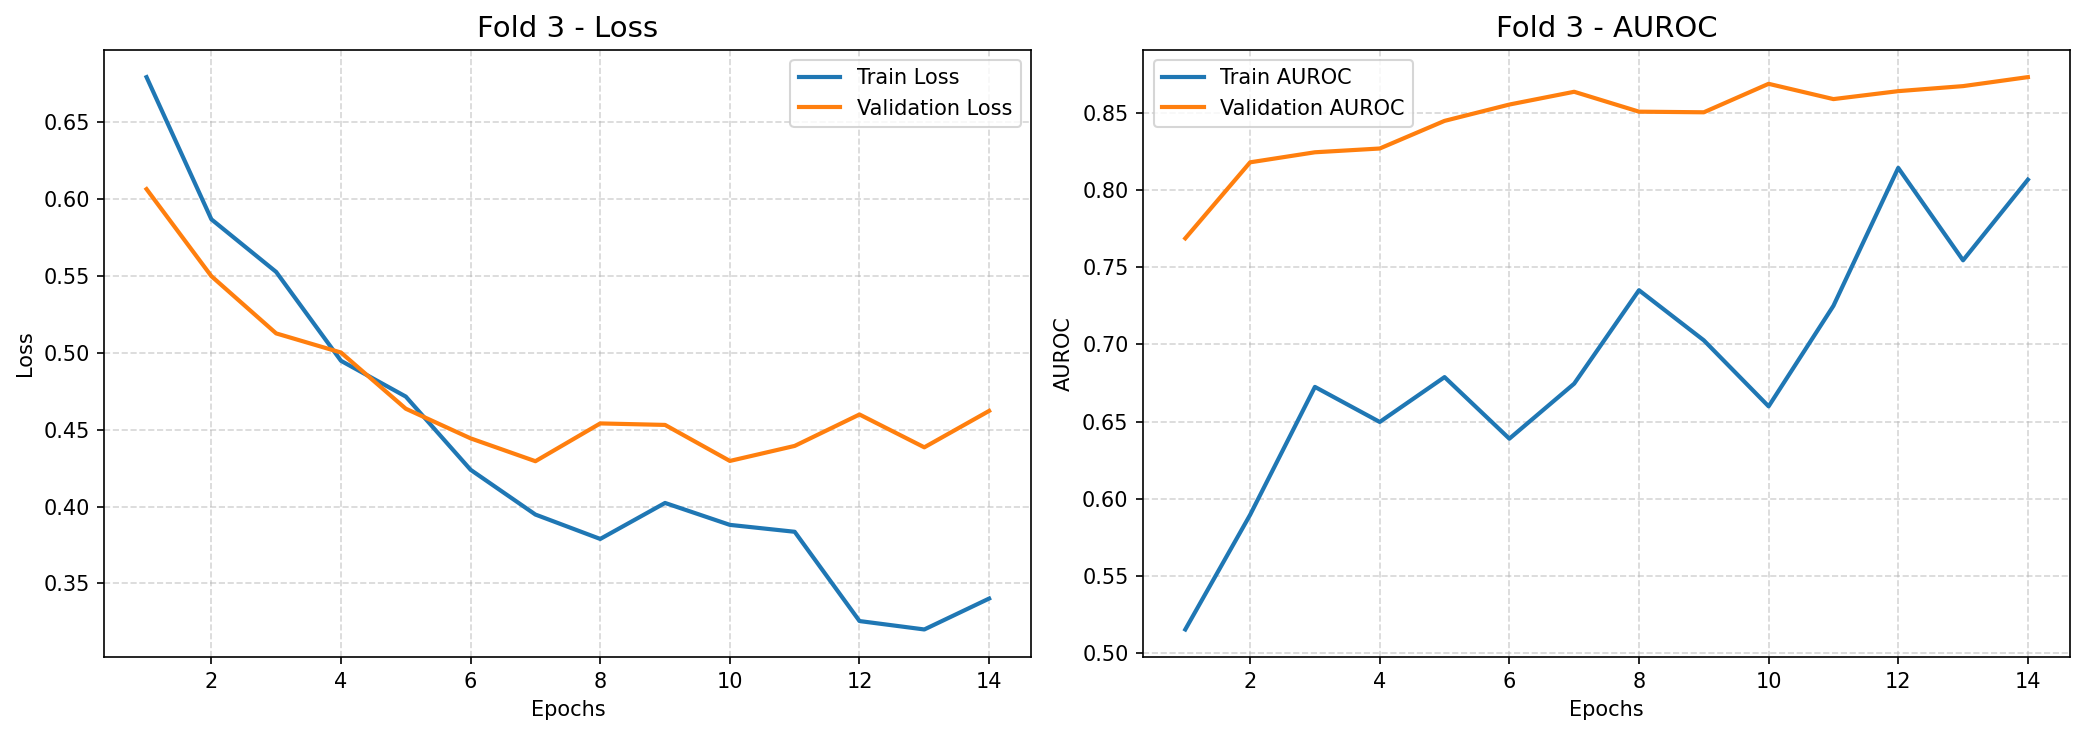


========== Fold 4/5 ==========


Epoch 1 - Train Loss: 0.6714 | Val Loss: 0.6347 | Train AUROC: 0.5214 | Val AUROC: 0.6803


Epoch 2 - Train Loss: 0.6019 | Val Loss: 0.5827 | Train AUROC: 0.6313 | Val AUROC: 0.7716


Epoch 3 - Train Loss: 0.5457 | Val Loss: 0.5341 | Train AUROC: 0.6441 | Val AUROC: 0.8087


Epoch 4 - Train Loss: 0.4912 | Val Loss: 0.4999 | Train AUROC: 0.6377 | Val AUROC: 0.8355


...

Epoch 11 - Train Loss: 0.3278 | Val Loss: 0.4868 | Train AUROC: 0.7712 | Val AUROC: 0.8440


Epoch 12 - Train Loss: 0.3443 | Val Loss: 0.4805 | Train AUROC: 0.7297 | Val AUROC: 0.8495


Epoch 13 - Train Loss: 0.3165 | Val Loss: 0.4847 | Train AUROC: 0.6912 | Val AUROC: 0.8510


Epoch 14 - Train Loss: 0.3635 | Val Loss: 0.4674 | Train AUROC: 0.7229 | Val AUROC: 0.8571


Epoch 15 - Train Loss: 0.3654 | Val Loss: 0.4756 | Train AUROC: 0.6425 | Val AUROC: 0.8577
⚠️ Fold 4 Early Stopping 발동 (최적 에포크 복원)


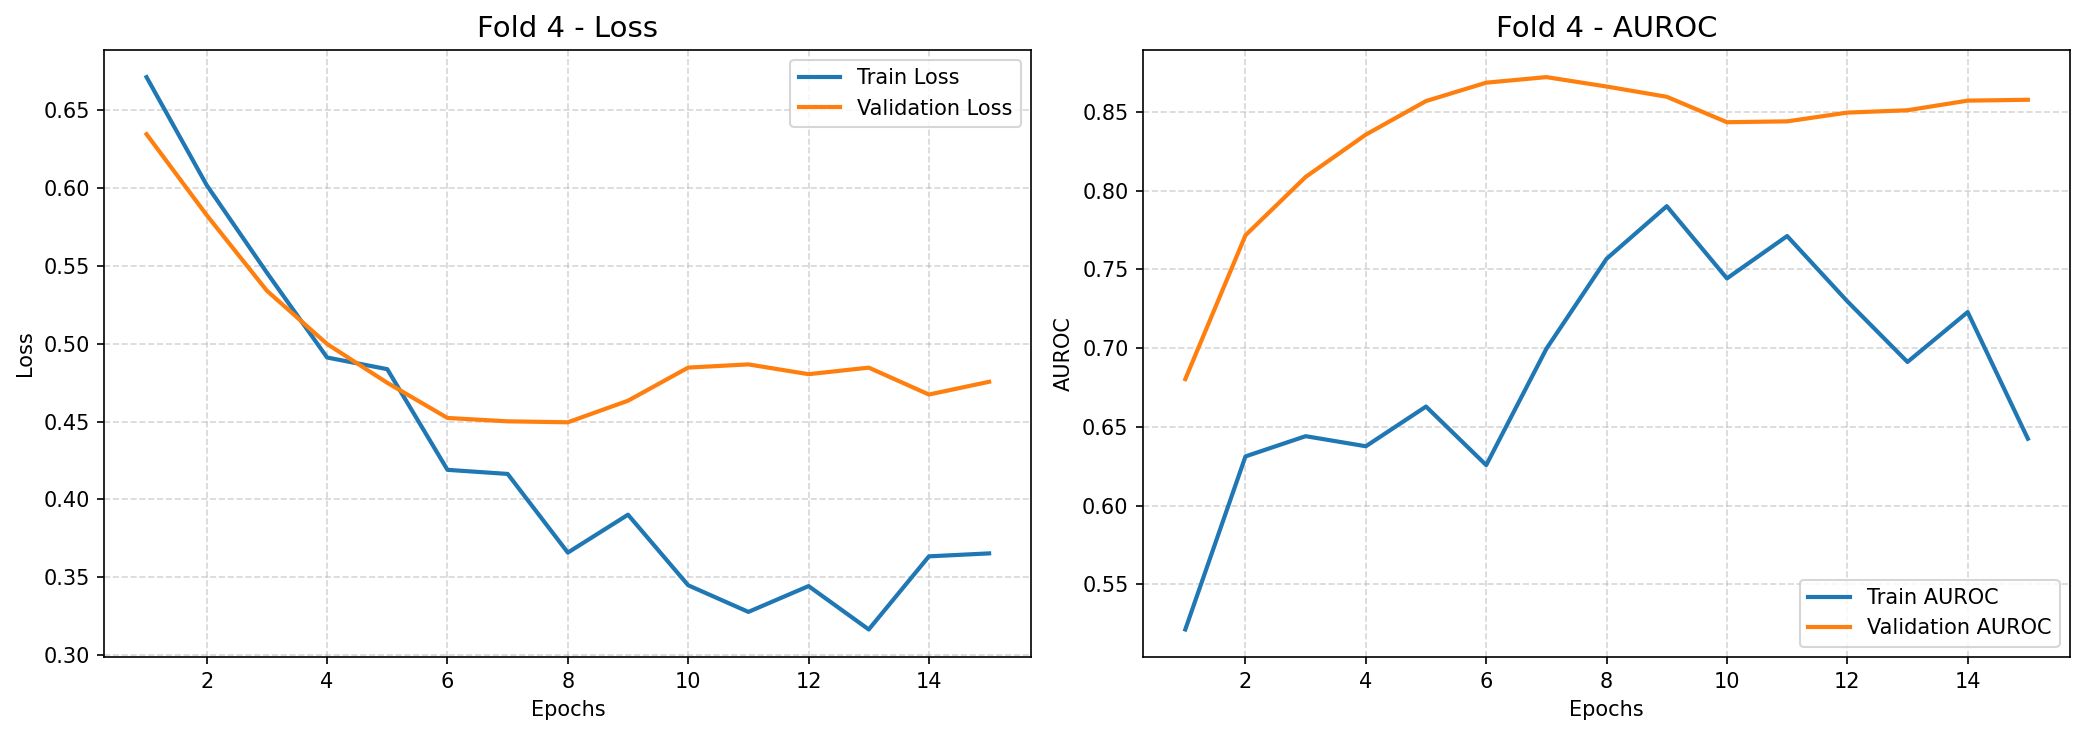


========== Fold 5/5 ==========


Epoch 1 - Train Loss: 0.6762 | Val Loss: 0.6329 | Train AUROC: 0.5102 | Val AUROC: 0.6986


Epoch 2 - Train Loss: 0.6055 | Val Loss: 0.5719 | Train AUROC: 0.6440 | Val AUROC: 0.7910


Epoch 3 - Train Loss: 0.5419 | Val Loss: 0.5122 | Train AUROC: 0.6796 | Val AUROC: 0.8275


Epoch 4 - Train Loss: 0.5119 | Val Loss: 0.4737 | Train AUROC: 0.7428 | Val AUROC: 0.8545


...

Epoch 23 - Train Loss: 0.3683 | Val Loss: 0.4295 | Train AUROC: 0.7118 | Val AUROC: 0.8778


Epoch 24 - Train Loss: 0.2740 | Val Loss: 0.4268 | Train AUROC: 0.7931 | Val AUROC: 0.8825


Epoch 25 - Train Loss: 0.2576 | Val Loss: 0.4214 | Train AUROC: 0.7263 | Val AUROC: 0.8837


Epoch 26 - Train Loss: 0.3037 | Val Loss: 0.4263 | Train AUROC: 0.6801 | Val AUROC: 0.8825


Epoch 27 - Train Loss: 0.3112 | Val Loss: 0.4321 | Train AUROC: 0.7419 | Val AUROC: 0.8736
⚠️ Fold 5 Early Stopping 발동 (최적 에포크 복원)


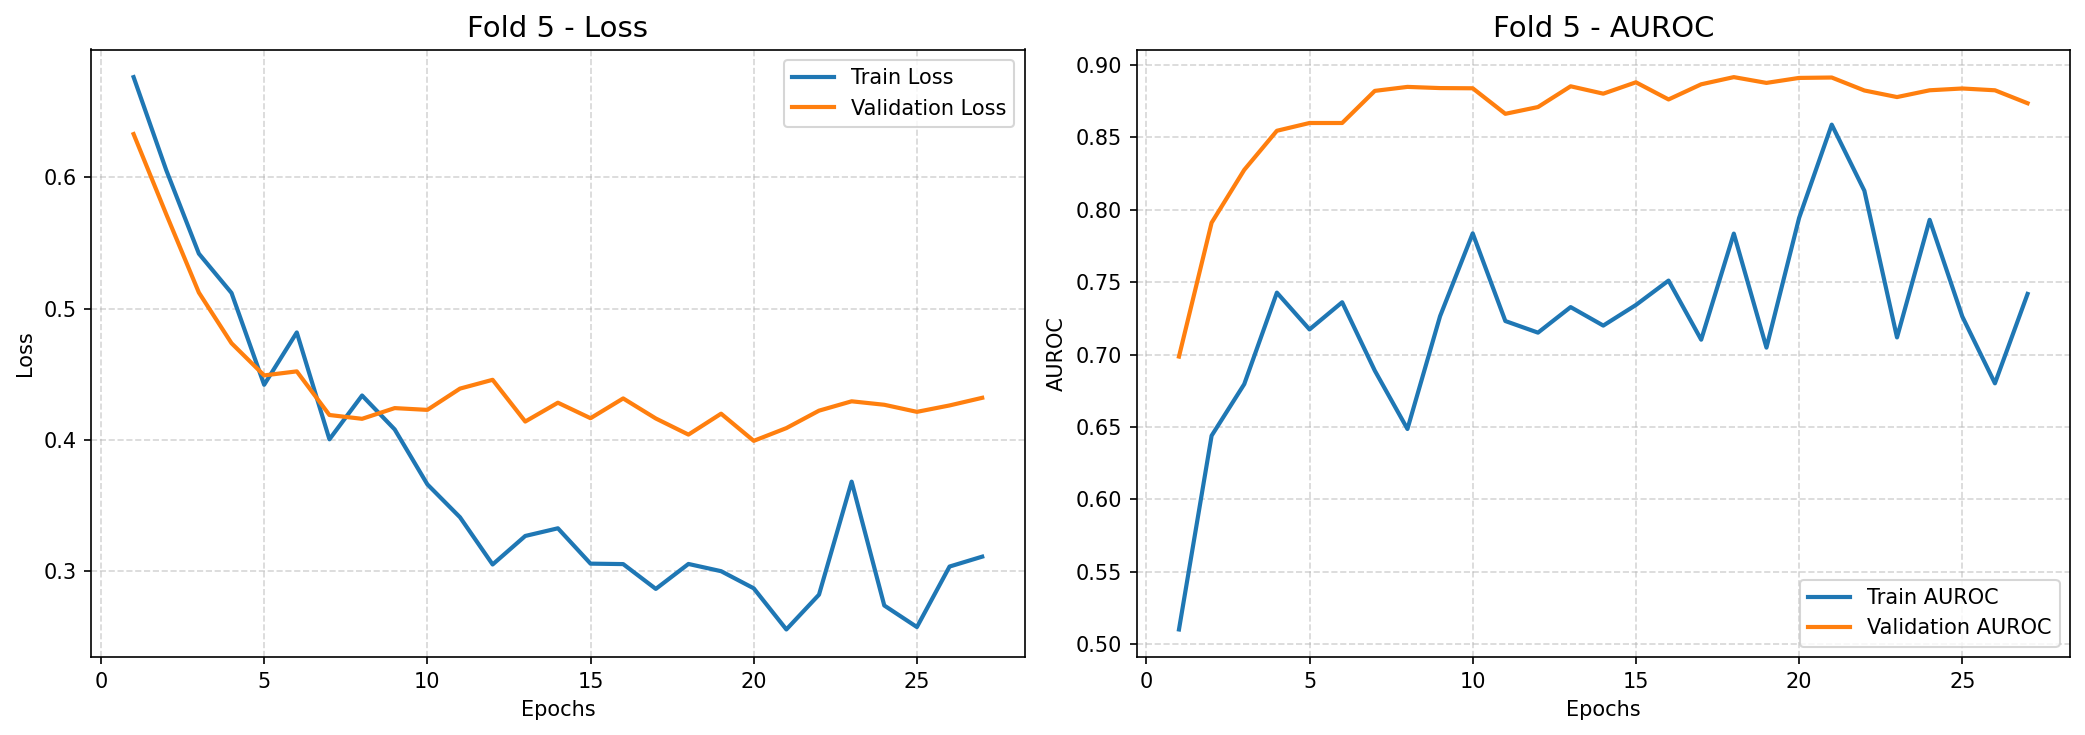

추론 완료! submission_strategy_B2.csv 생성됨.


## 전략 C: Mixup 제거 후 원복 (정통 학습)

In [26]:
# ==========================================
# 전략 C: 정통 학습 (Mixup X, Val Loss Early Stopping)
# ==========================================
print(f"[{DEVICE}] 전략 C: 정통 학습(Mixup 없음)을 시작합니다...")

# train_loader, val_loader가 분리되어 있다고 가정
EPOCHS = 50
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

patience, counter = 7, 0
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train"):
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        optimizer.zero_grad()
        
        # Mixup 제거! 원본 이미지 그대로 모델 통과
        outputs = model(images).squeeze(-1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    scheduler.step()
    
    model.eval()
    running_val_loss = 0.0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            outputs = model(images).squeeze(-1)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
            val_targets.extend(labels.cpu().view(-1).numpy())
            
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_auroc = roc_auc_score(val_targets, val_preds)
    
    print(f"Epoch {epoch+1} - Train Loss: {running_train_loss/len(train_loader):.4f} | Val Loss: {epoch_val_loss:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⚠️ Early Stopping 발동")
            break

model.load_state_dict(best_model_wts)

# 추론
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
predictions, img_ids = [], []
with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
        if probs.ndim == 0: probs = [probs.item()]
        predictions.extend(probs)
        img_ids.extend(ids)

pd.DataFrame({'id': img_ids, 'dusty_prob': predictions}).to_csv(os.path.join(path, 'submission_strategy_C2.csv'), index=False)
print("추론 완료! submission_strategy_C.csv 생성됨.")

[cuda] 전략 C: 정통 학습(Mixup 없음)을 시작합니다...


Epoch 1/50 Train: 100%|██████████| 23/23 [00:04<00:00,  5.15it/s]


Epoch 1 - Train Loss: 0.6583 | Val Loss: 0.6025 | Val AUROC: 0.7472


Epoch 2/50 Train: 100%|██████████| 23/23 [00:04<00:00,  5.21it/s]


Epoch 2 - Train Loss: 0.5815 | Val Loss: 0.5452 | Val AUROC: 0.8156


...

Epoch 13 - Train Loss: 0.1893 | Val Loss: 0.4582 | Val AUROC: 0.8791


Epoch 14/50 Train: 100%|██████████| 23/23 [00:04<00:00,  4.89it/s]


Epoch 14 - Train Loss: 0.1563 | Val Loss: 0.4525 | Val AUROC: 0.8837
⚠️ Early Stopping 발동


Inference: 100%|██████████| 15/15 [00:01<00:00,  8.28it/s]


추론 완료! submission_strategy_C.csv 생성됨.


[cuda] 전략 C: 정통 학습(Mixup 없음)을 시작합니다...


Epoch 1/50 Train: 100%|██████████| 23/23 [00:04<00:00,  4.93it/s]


Epoch 1 - Train Loss: 0.6555 | Val Loss: 0.6043 | Train AUROC: 0.6345 | Val AUROC: 0.7251


Epoch 2/50 Train: 100%|██████████| 23/23 [00:04<00:00,  5.05it/s]


Epoch 2 - Train Loss: 0.5548 | Val Loss: 0.5387 | Train AUROC: 0.8061 | Val AUROC: 0.8026


...

Epoch 12 - Train Loss: 0.1872 | Val Loss: 0.4427 | Train AUROC: 0.9853 | Val AUROC: 0.8738


Epoch 13/50 Train: 100%|██████████| 23/23 [00:04<00:00,  4.94it/s]


Epoch 13 - Train Loss: 0.2011 | Val Loss: 0.4883 | Train AUROC: 0.9782 | Val AUROC: 0.8667


Epoch 14/50 Train: 100%|██████████| 23/23 [00:04<00:00,  4.98it/s]


Epoch 14 - Train Loss: 0.1666 | Val Loss: 0.4752 | Train AUROC: 0.9889 | Val AUROC: 0.8713
⚠️ Early Stopping 발동


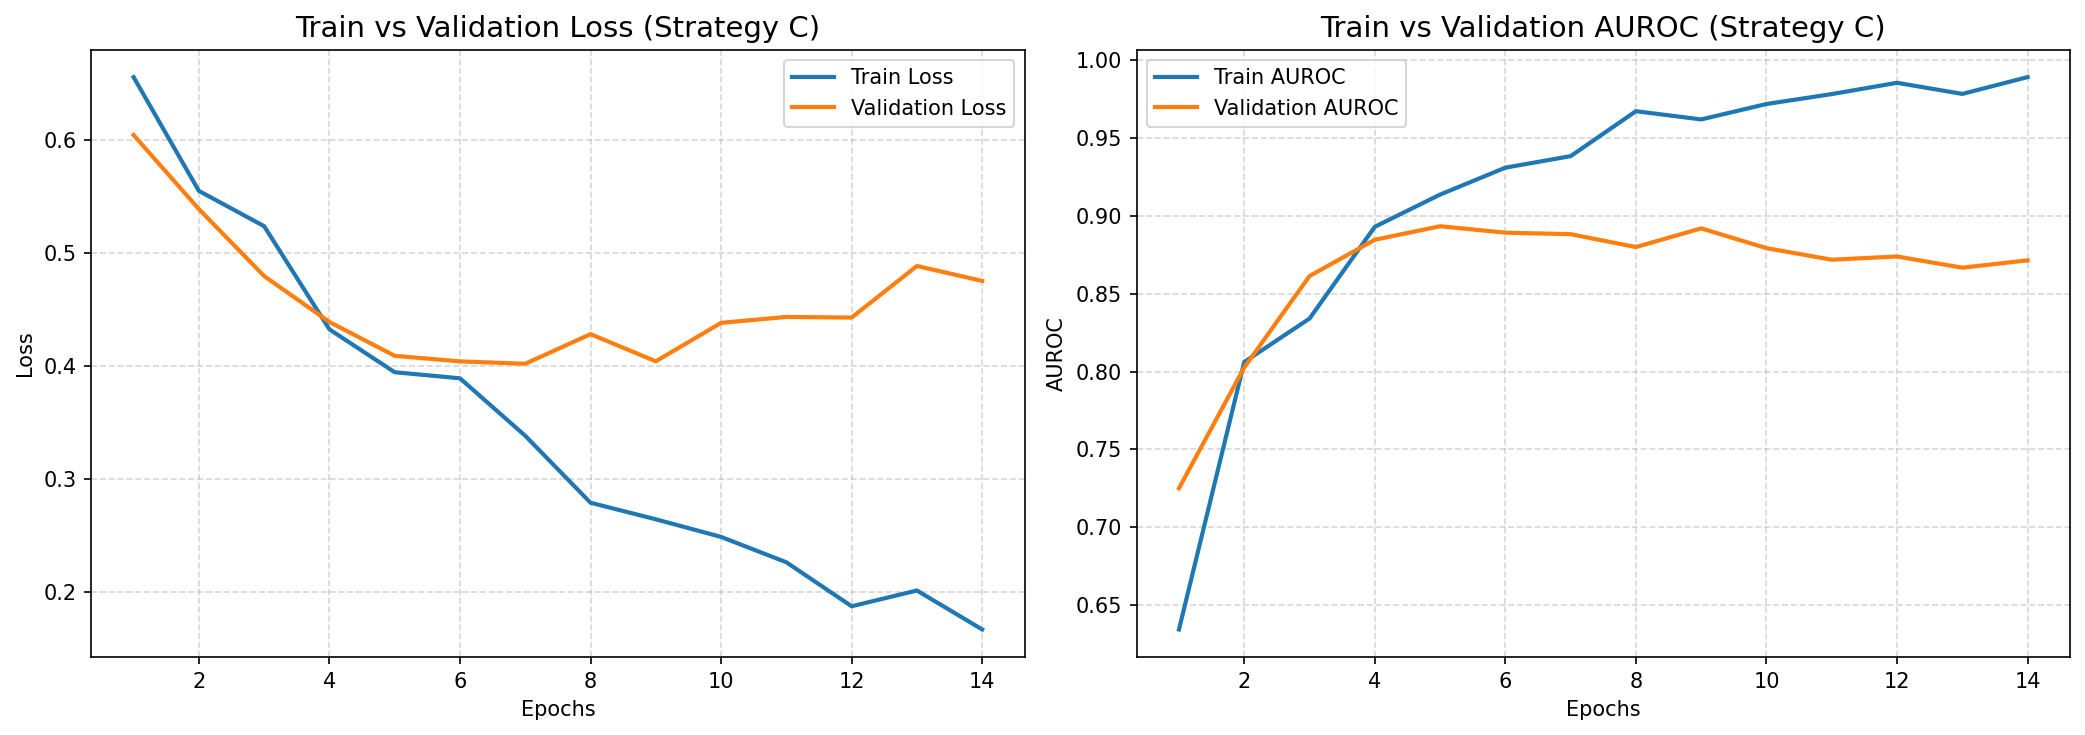

Inference: 100%|██████████| 15/15 [00:01<00:00,  7.97it/s]

추론 완료! submission_strategy_C2.csv 생성됨.


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import copy  
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from tqdm import tqdm

# [추가] AUROC 계산을 위한 라이브러리 임포트
from sklearn.metrics import roc_auc_score 

# ==========================================
# 전략 C: 정통 학습 (Mixup X, Val Loss Early Stopping)
# ==========================================
print(f"[{DEVICE}] 전략 C: 정통 학습(Mixup 없음)을 시작합니다...")

# train_loader, val_loader가 분리되어 있다고 가정
EPOCHS = 50
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

patience, counter = 7, 0
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

# --- [추가] 평가지표 기록을 위한 히스토리 딕셔너리 ---
history = {
    'train_loss': [],
    'val_loss': [],
    'train_auroc': [],
    'val_auroc': []
}

for epoch in range(EPOCHS):
    # ---------- 1. Train Phase ----------
    model.train()
    running_train_loss = 0.0
    
    # [추가] Train AUROC 기록용 리스트
    train_preds = []
    train_targets = []
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train"):
        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
        optimizer.zero_grad()
        
        # Mixup 제거! 원본 이미지 그대로 모델 통과
        outputs = model(images).squeeze(-1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        
        # [추가] Train 예측 확률값 및 정답 수집 (Mixup이 없으므로 간결하게 매칭)
        with torch.no_grad():
            probs = torch.sigmoid(outputs)
            train_preds.extend(probs.cpu().view(-1).numpy())
            train_targets.extend(labels.cpu().view(-1).numpy())
            
    scheduler.step()
    epoch_train_loss = running_train_loss / len(train_loader)
    
    # [추가] Train AUROC 계산
    try:
        epoch_train_auroc = roc_auc_score(train_targets, train_preds)
    except ValueError:
        epoch_train_auroc = 0.5
    
    # ---------- 2. Validation Phase ----------
    model.eval()
    running_val_loss = 0.0
    val_preds, val_targets = [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            outputs = model(images).squeeze(-1)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
            val_targets.extend(labels.cpu().view(-1).numpy())
            
    epoch_val_loss = running_val_loss / len(val_loader)
    
    # Val AUROC 계산
    try:
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
    except ValueError:
        epoch_val_auroc = 0.5
    
    # --- [추가] 히스토리에 현재 에포크 데이터 기록 ---
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_auroc'].append(epoch_train_auroc)
    history['val_auroc'].append(epoch_val_auroc)
    
    # [수정] Print문에 Train Loss 및 Train AUROC 추가 출력
    print(f"Epoch {epoch+1} - "
          f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
    
    # ---------- 3. Early Stopping Check ----------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⚠️ Early Stopping 발동")
            break

# 최적 가중치로 복원
model.load_state_dict(best_model_wts)


# --- [추가] 최종 Train/Val Loss 및 AUROC 그래프 시각화 ---
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5), dpi=150)

# 왼쪽 서브플롯: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Train vs Validation Loss (Strategy C)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 오른쪽 서브플롯: AUROC
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_auroc'], label='Train AUROC', linewidth=2)
plt.plot(epochs_range, history['val_auroc'], label='Validation AUROC', linewidth=2)
plt.title('Train vs Validation AUROC (Strategy C)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('AUROC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# 그래프 이미지 로컬 파일 저장
plt.savefig('strategy_c_learning_curves.png', bbox_inches='tight')
plt.show()


# ---------- 4. 테스트 추론 및 제출 ----------
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
predictions, img_ids = [], []
with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
        if probs.ndim == 0: probs = [probs.item()]
        predictions.extend(probs)
        img_ids.extend(ids)

pd.DataFrame({'id': img_ids, 'dusty_prob': predictions}).to_csv(os.path.join(path, 'submission_strategy_C3.csv'), index=False)
print("추론 완료! submission_strategy_C2.csv 생성됨.")

# 전략 D: 5-Fold 앙상블 (Mixup O, Val AUROC Early Stopping)

In [27]:
# ==========================================
# 전략 D: 5-Fold 앙상블 (Mixup O, Val AUROC Early Stopping)
# ==========================================
from sklearn.model_selection import StratifiedKFold

K_FOLDS = 5
EPOCHS = 50
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['label'].values 

sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_preds_ensemble = np.zeros(len(test_dataset))

print(f"[{DEVICE}] 전략 D: 통합 앙상블(AUROC 기반 조기종료) 시작...")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, all_labels)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    train_loader = DataLoader(SolarPanelDataset(fold_train_df, train_img_dir, transform=train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SolarPanelDataset(fold_val_df, train_img_dir, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False)
    
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    patience, counter = 7, 0
    best_val_auroc = 0.0 # Loss가 아닌 AUROC 기준이므로 0.0으로 시작
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
        scheduler.step()
        
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images).squeeze(-1)
                val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
                val_targets.extend(labels.cpu().view(-1).numpy())
                
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
        print(f"Epoch {epoch+1} - Val AUROC: {epoch_val_auroc:.4f}")
        
        # Loss 감소가 아닌 AUROC 증가 여부를 체크합니다.
        if epoch_val_auroc > best_val_auroc:
            best_val_auroc = epoch_val_auroc
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("⚠️ Early Stopping 발동 (AUROC 개선 없음)")
                break
                
    model.load_state_dict(best_model_wts)
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
            if probs.ndim == 0: probs = [probs.item()]
            fold_preds.extend(probs)
    test_preds_ensemble += np.array(fold_preds)

test_preds_ensemble /= K_FOLDS
pd.DataFrame({'id': sub_df['id'], 'dusty_prob': test_preds_ensemble}).to_csv(os.path.join(path, 'submission_strategy_D2.csv'), index=False)
print("추론 완료! submission_strategy_D.csv 생성됨.")

[cuda] 전략 D: 통합 앙상블(AUROC 기반 조기종료) 시작...

========== Fold 1/5 ==========
Epoch 1 - Val AUROC: 0.6915
Epoch 2 - Val AUROC: 0.7912
Epoch 3 - Val AUROC: 0.8326
Epoch 4 - Val AUROC: 0.8456
Epoch 5 - Val AUROC: 0.8491
Epoch 6 - Val AUROC: 0.8613
Epoch 7 - Val AUROC: 0.8636
Epoch 8 - Val AUROC: 0.8573
Epoch 9 - Val AUROC: 0.8525
Epoch 10 - Val AUROC: 0.8526
Epoch 11 - Val AUROC: 0.8400
Epoch 12 - Val AUROC: 0.8399
Epoch 13 - Val AUROC: 0.8403
Epoch 14 - Val AUROC: 0.8280
⚠️ Early Stopping 발동 (AUROC 개선 없음)

========== Fold 2/5 ==========
Epoch 1 - Val AUROC: 0.7700
Epoch 2 - Val AUROC: 0.7938
Epoch 3 - Val AUROC: 0.7993
Epoch 4 - Val AUROC: 0.8178
Epoch 5 - Val AUROC: 0.8326
Epoch 6 - Val AUROC: 0.8396
Epoch 7 - Val AUROC: 0.8478
Epoch 8 - Val AUROC: 0.8490
Epoch 9 - Val AUROC: 0.8739
Epoch 10 - Val AUROC: 0.8852
Epoch 11 - Val AUROC: 0.8932
Epoch 12 - Val AUROC: 0.8866
Epoch 13 - Val AUROC: 0.8680
Epoch 14 - Val AUROC: 0.8909
Epoch 15 - Val AUROC: 0.8782
Epoch 16 - Val AUROC: 0.8894
Epoch 17

[cuda] 전략 D: 통합 앙상블(AUROC 기반 조기종료) 시작...

========== Fold 1/5 ==========


Epoch 1 - Train Loss: 0.6586 | Val Loss: 0.5953 | Train AUROC: 0.5608 | Val AUROC: 0.7965
  ▶ Val AUROC가 개선되었습니다! (0.0000 ➡️ 0.7965). 모델 가중치를 저장합니다.


Epoch 2 - Train Loss: 0.5998 | Val Loss: 0.5347 | Train AUROC: 0.6568 | Val AUROC: 0.8316
  ▶ Val AUROC가 개선되었습니다! (0.7965 ➡️ 0.8316). 모델 가중치를 저장합니다.


Epoch 3 - Train Loss: 0.5393 | Val Loss: 0.4913 | Train AUROC: 0.6821 | Val AUROC: 0.8540
  ▶ Val AUROC가 개선되었습니다! (0.8316 ➡️ 0.8540). 모델 가중치를 저장합니다.


Epoch 4 - Train Loss: 0.5097 | Val Loss: 0.4558 | Train AUROC: 0.7226 | Val AUROC: 0.8750
  ▶ Val AUROC가 개선되었습니다! (0.8540 ➡️ 0.8750). 모델 가중치를 저장합니다.


...

Epoch 11 - Train Loss: 0.3721 | Val Loss: 0.4656 | Train AUROC: 0.6399 | Val AUROC: 0.8659


Epoch 12 - Train Loss: 0.2860 | Val Loss: 0.4840 | Train AUROC: 0.7603 | Val AUROC: 0.8635


Epoch 13 - Train Loss: 0.3217 | Val Loss: 0.5174 | Train AUROC: 0.7245 | Val AUROC: 0.8455


Epoch 14 - Train Loss: 0.3196 | Val Loss: 0.4945 | Train AUROC: 0.7532 | Val AUROC: 0.8521


Epoch 15 - Train Loss: 0.3080 | Val Loss: 0.5160 | Train AUROC: 0.6834 | Val AUROC: 0.8483
⚠️ Fold 1 Early Stopping 발동 (AUROC 개선 없음)


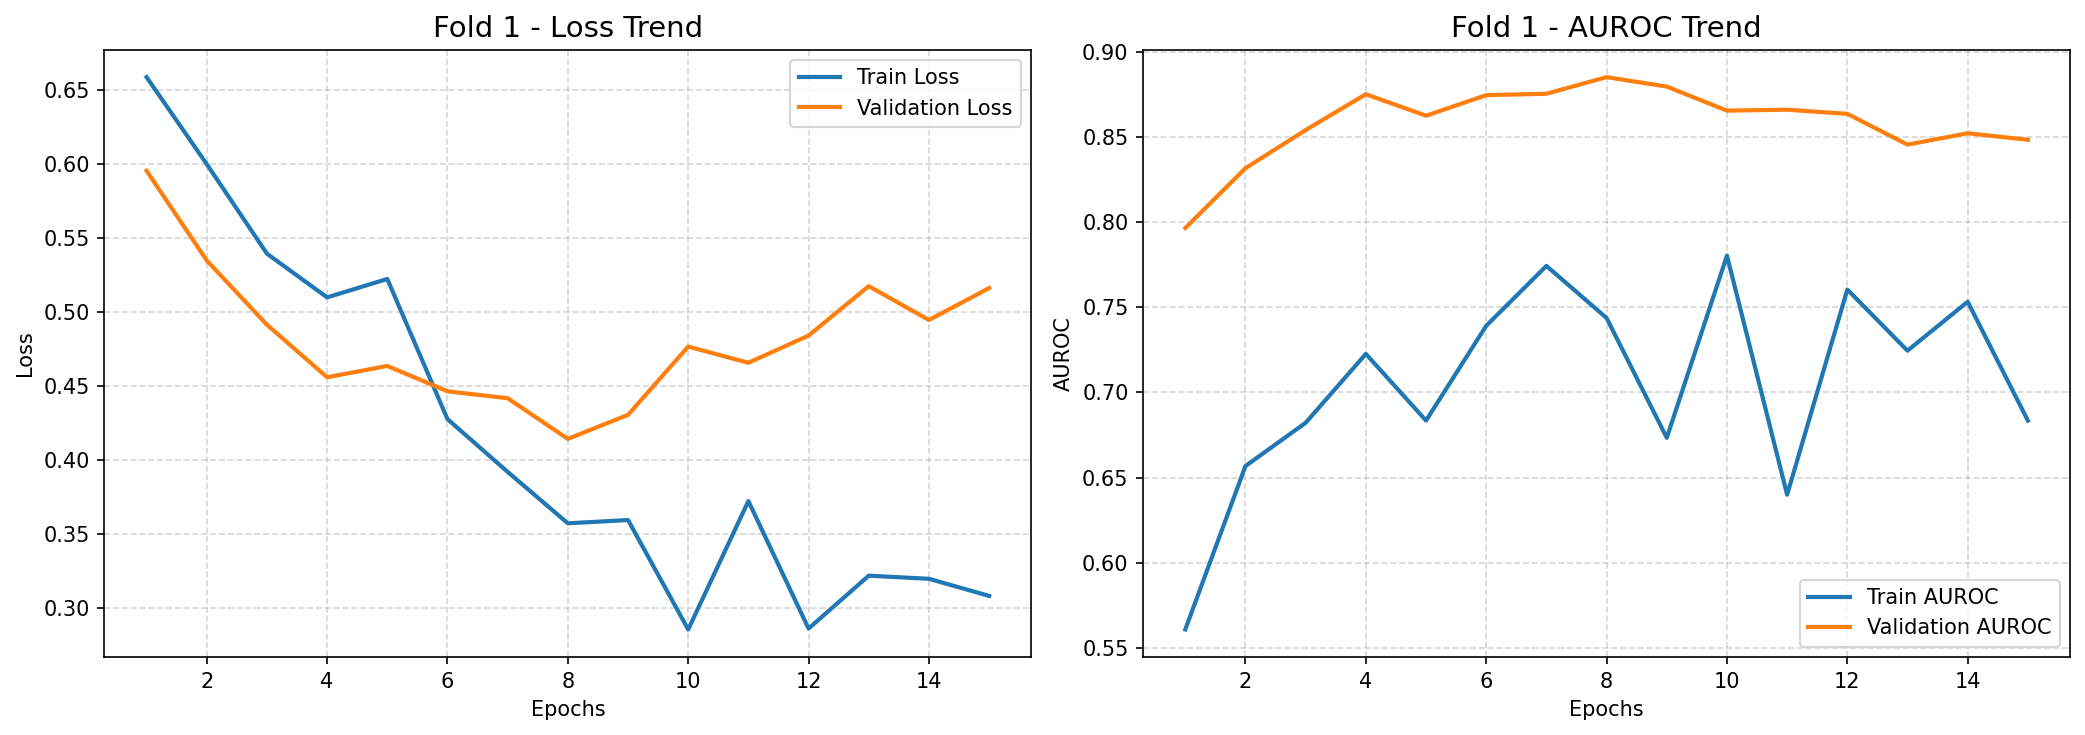


========== Fold 2/5 ==========


Epoch 1 - Train Loss: 0.6736 | Val Loss: 0.6357 | Train AUROC: 0.5461 | Val AUROC: 0.6863
  ▶ Val AUROC가 개선되었습니다! (0.0000 ➡️ 0.6863). 모델 가중치를 저장합니다.


Epoch 2 - Train Loss: 0.5922 | Val Loss: 0.5865 | Train AUROC: 0.6706 | Val AUROC: 0.7464
  ▶ Val AUROC가 개선되었습니다! (0.6863 ➡️ 0.7464). 모델 가중치를 저장합니다.


Epoch 3 - Train Loss: 0.5460 | Val Loss: 0.5626 | Train AUROC: 0.6267 | Val AUROC: 0.7573
  ▶ Val AUROC가 개선되었습니다! (0.7464 ➡️ 0.7573). 모델 가중치를 저장합니다.


Epoch 4 - Train Loss: 0.5302 | Val Loss: 0.5580 | Train AUROC: 0.7642 | Val AUROC: 0.7661
  ▶ Val AUROC가 개선되었습니다! (0.7573 ➡️ 0.7661). 모델 가중치를 저장합니다.


...

Epoch 23 - Train Loss: 0.2261 | Val Loss: 0.4537 | Train AUROC: 0.7813 | Val AUROC: 0.8672


Epoch 24 - Train Loss: 0.2992 | Val Loss: 0.4656 | Train AUROC: 0.6634 | Val AUROC: 0.8649


Epoch 25 - Train Loss: 0.2442 | Val Loss: 0.4796 | Train AUROC: 0.7259 | Val AUROC: 0.8554


Epoch 26 - Train Loss: 0.2657 | Val Loss: 0.4642 | Train AUROC: 0.6948 | Val AUROC: 0.8672


Epoch 27 - Train Loss: 0.2887 | Val Loss: 0.4745 | Train AUROC: 0.6982 | Val AUROC: 0.8581
⚠️ Fold 2 Early Stopping 발동 (AUROC 개선 없음)


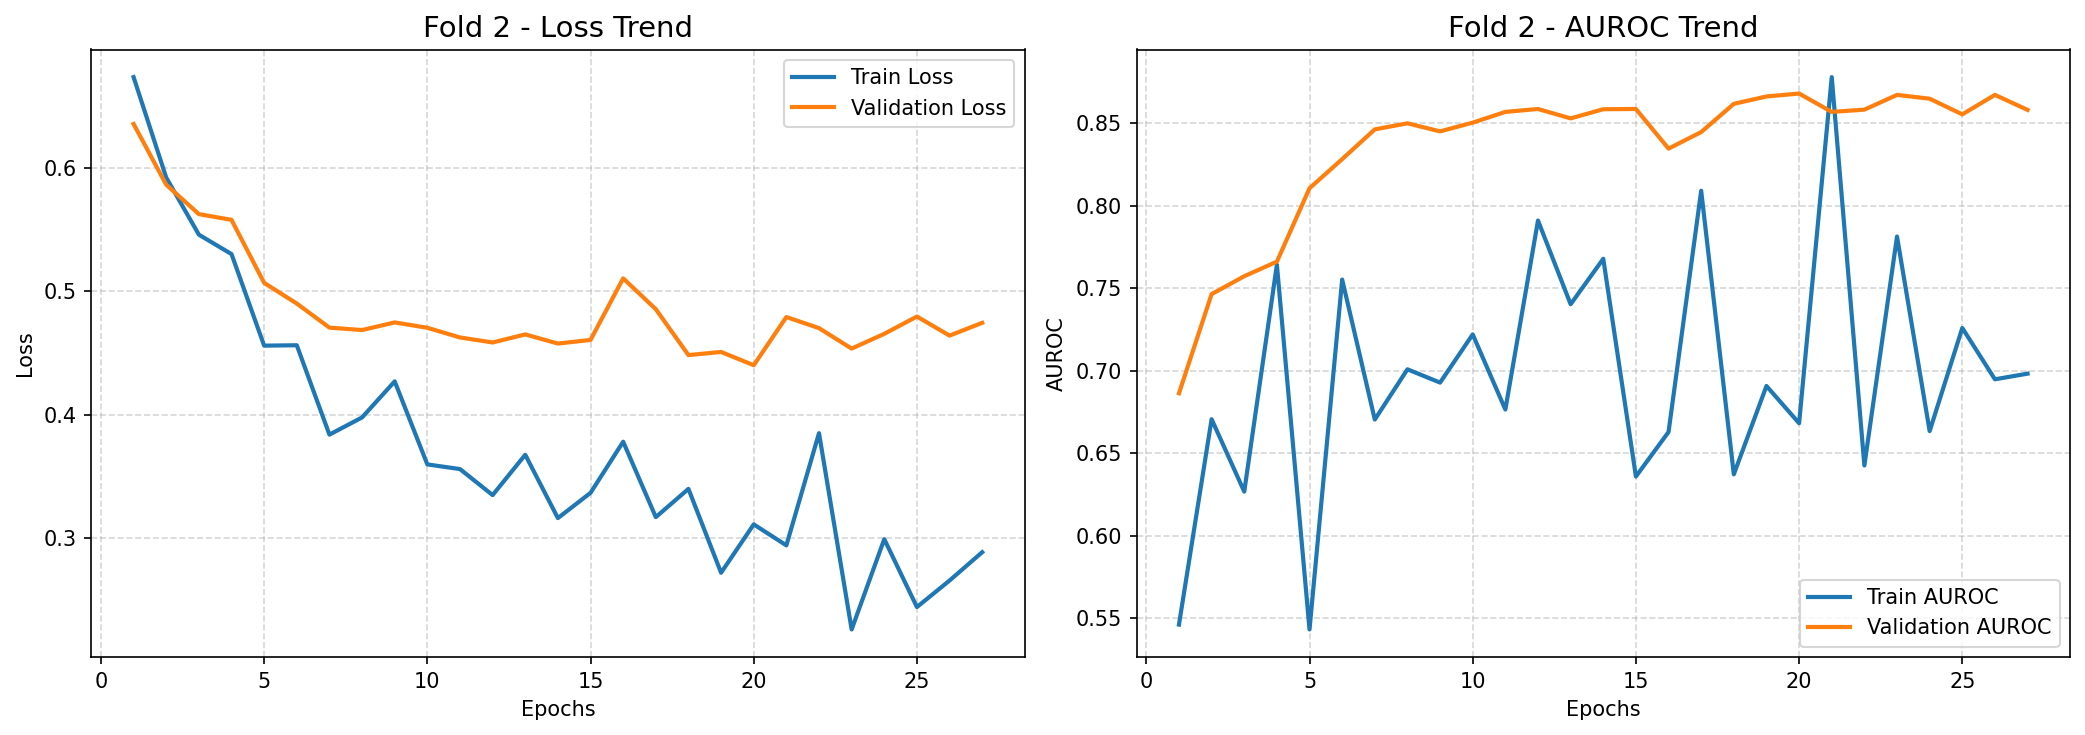


========== Fold 3/5 ==========


Epoch 1 - Train Loss: 0.6814 | Val Loss: 0.6171 | Train AUROC: 0.5371 | Val AUROC: 0.7308
  ▶ Val AUROC가 개선되었습니다! (0.0000 ➡️ 0.7308). 모델 가중치를 저장합니다.


Epoch 2 - Train Loss: 0.5991 | Val Loss: 0.5627 | Train AUROC: 0.7154 | Val AUROC: 0.7938
  ▶ Val AUROC가 개선되었습니다! (0.7308 ➡️ 0.7938). 모델 가중치를 저장합니다.


Epoch 3 - Train Loss: 0.5393 | Val Loss: 0.5246 | Train AUROC: 0.6115 | Val AUROC: 0.8227
  ▶ Val AUROC가 개선되었습니다! (0.7938 ➡️ 0.8227). 모델 가중치를 저장합니다.


Epoch 4 - Train Loss: 0.5147 | Val Loss: 0.4958 | Train AUROC: 0.5862 | Val AUROC: 0.8364
  ▶ Val AUROC가 개선되었습니다! (0.8227 ➡️ 0.8364). 모델 가중치를 저장합니다.


...

Epoch 14 - Train Loss: 0.3167 | Val Loss: 0.4546 | Train AUROC: 0.7292 | Val AUROC: 0.8695


Epoch 15 - Train Loss: 0.3777 | Val Loss: 0.4286 | Train AUROC: 0.7363 | Val AUROC: 0.8643


Epoch 16 - Train Loss: 0.3194 | Val Loss: 0.4301 | Train AUROC: 0.6939 | Val AUROC: 0.8673


Epoch 17 - Train Loss: 0.3135 | Val Loss: 0.4386 | Train AUROC: 0.6931 | Val AUROC: 0.8665


Epoch 18 - Train Loss: 0.3818 | Val Loss: 0.4099 | Train AUROC: 0.8115 | Val AUROC: 0.8750
⚠️ Fold 3 Early Stopping 발동 (AUROC 개선 없음)


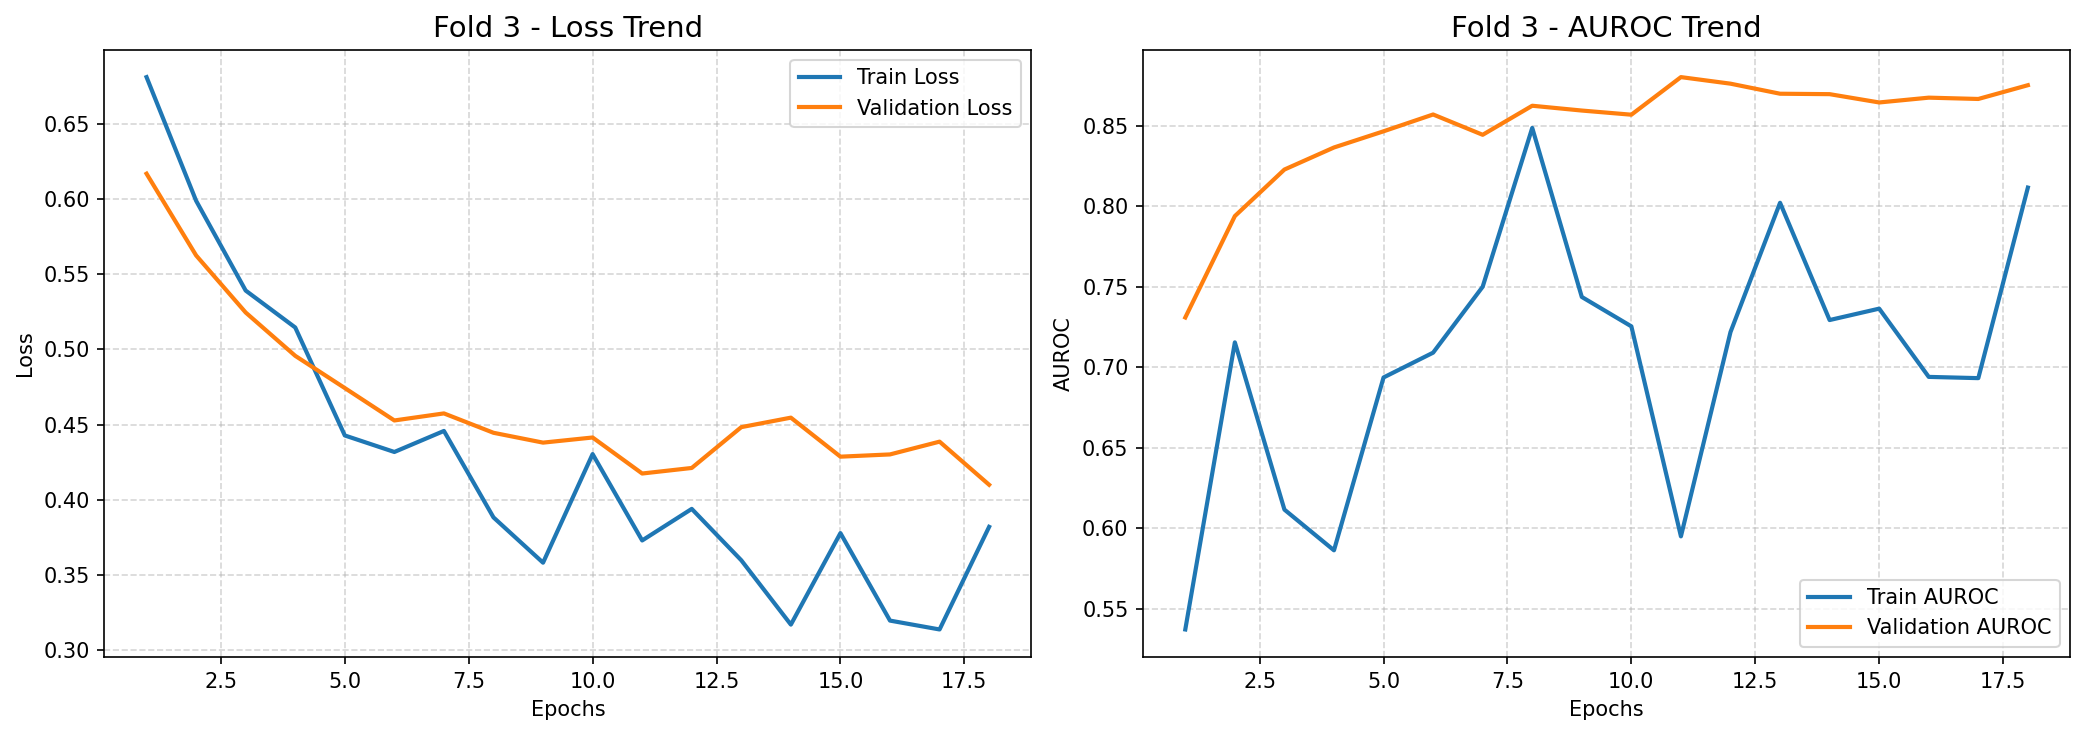


========== Fold 4/5 ==========


Epoch 1 - Train Loss: 0.6738 | Val Loss: 0.6298 | Train AUROC: 0.5845 | Val AUROC: 0.6688
  ▶ Val AUROC가 개선되었습니다! (0.0000 ➡️ 0.6688). 모델 가중치를 저장합니다.


Epoch 2 - Train Loss: 0.6237 | Val Loss: 0.5835 | Train AUROC: 0.6176 | Val AUROC: 0.7573
  ▶ Val AUROC가 개선되었습니다! (0.6688 ➡️ 0.7573). 모델 가중치를 저장합니다.


Epoch 3 - Train Loss: 0.5693 | Val Loss: 0.5537 | Train AUROC: 0.6532 | Val AUROC: 0.7904
  ▶ Val AUROC가 개선되었습니다! (0.7573 ➡️ 0.7904). 모델 가중치를 저장합니다.


Epoch 4 - Train Loss: 0.5040 | Val Loss: 0.5200 | Train AUROC: 0.6274 | Val AUROC: 0.8206
  ▶ Val AUROC가 개선되었습니다! (0.7904 ➡️ 0.8206). 모델 가중치를 저장합니다.


...

Epoch 12 - Train Loss: 0.3566 | Val Loss: 0.4865 | Train AUROC: 0.5918 | Val AUROC: 0.8444


Epoch 13 - Train Loss: 0.3605 | Val Loss: 0.5088 | Train AUROC: 0.6288 | Val AUROC: 0.8383


Epoch 14 - Train Loss: 0.3259 | Val Loss: 0.5096 | Train AUROC: 0.7698 | Val AUROC: 0.8383


Epoch 15 - Train Loss: 0.3878 | Val Loss: 0.5133 | Train AUROC: 0.6973 | Val AUROC: 0.8300


Epoch 16 - Train Loss: 0.3313 | Val Loss: 0.5015 | Train AUROC: 0.7538 | Val AUROC: 0.8408
⚠️ Fold 4 Early Stopping 발동 (AUROC 개선 없음)


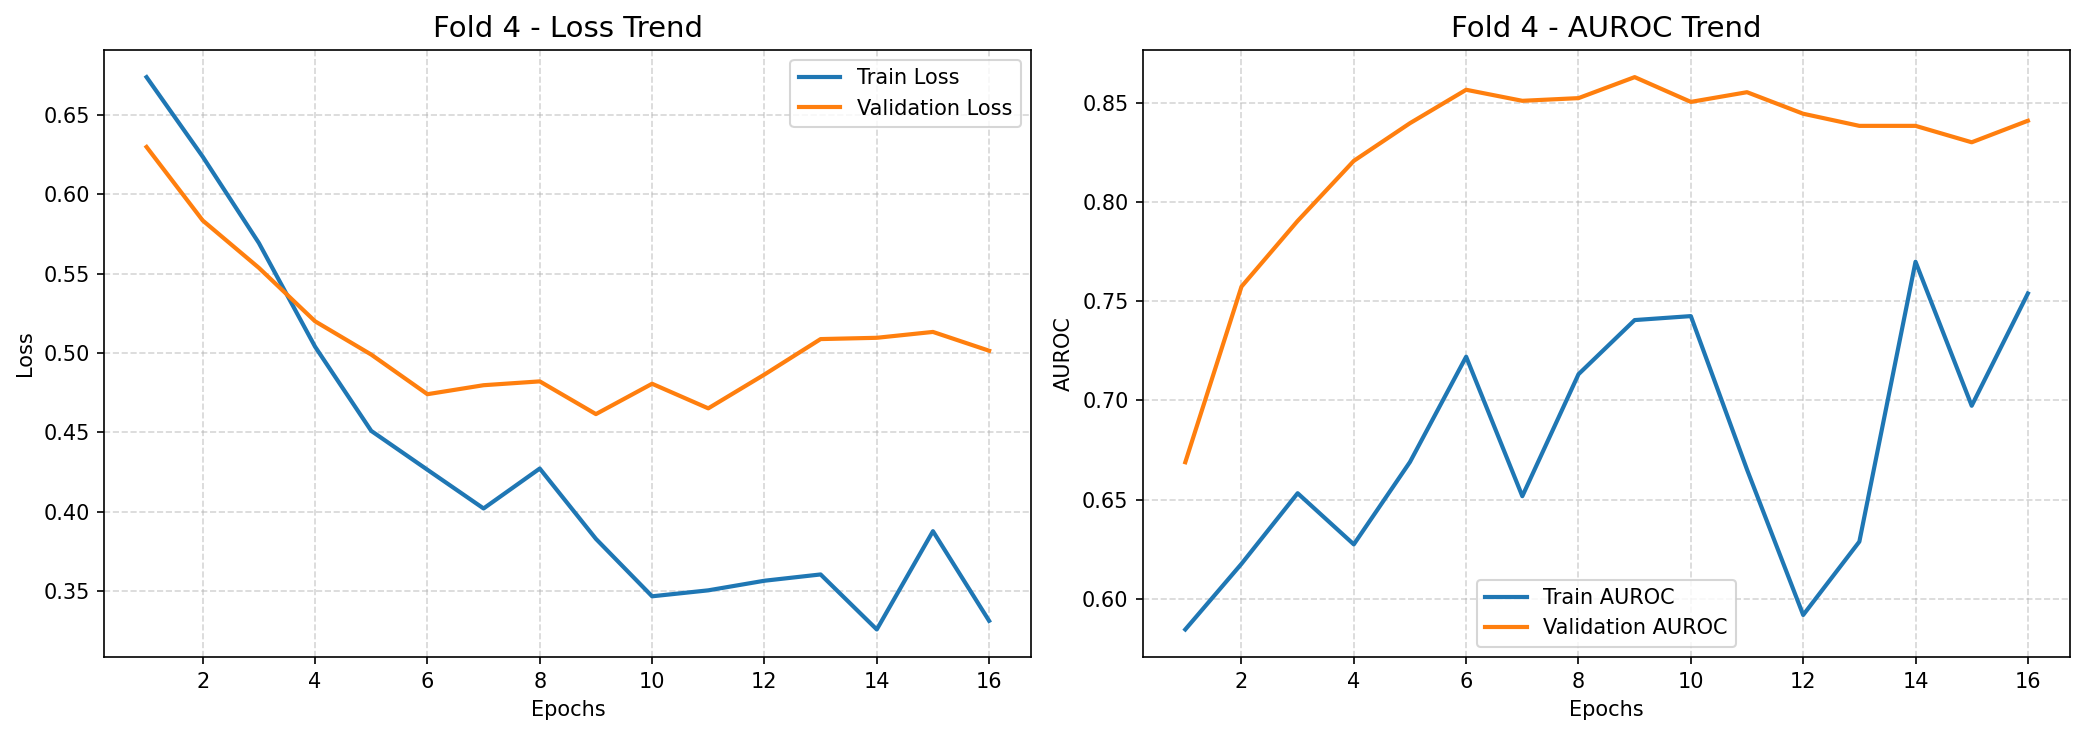


========== Fold 5/5 ==========


Epoch 1 - Train Loss: 0.6648 | Val Loss: 0.6120 | Train AUROC: 0.5356 | Val AUROC: 0.7180
  ▶ Val AUROC가 개선되었습니다! (0.0000 ➡️ 0.7180). 모델 가중치를 저장합니다.


Epoch 2 - Train Loss: 0.5927 | Val Loss: 0.5555 | Train AUROC: 0.6082 | Val AUROC: 0.7883
  ▶ Val AUROC가 개선되었습니다! (0.7180 ➡️ 0.7883). 모델 가중치를 저장합니다.


Epoch 3 - Train Loss: 0.5502 | Val Loss: 0.5141 | Train AUROC: 0.6209 | Val AUROC: 0.8189
  ▶ Val AUROC가 개선되었습니다! (0.7883 ➡️ 0.8189). 모델 가중치를 저장합니다.


Epoch 4 - Train Loss: 0.5068 | Val Loss: 0.4803 | Train AUROC: 0.6324 | Val AUROC: 0.8382
  ▶ Val AUROC가 개선되었습니다! (0.8189 ➡️ 0.8382). 모델 가중치를 저장합니다.


...

Epoch 31 - Train Loss: 0.2158 | Val Loss: 0.4070 | Train AUROC: 0.7466 | Val AUROC: 0.8890


Epoch 32 - Train Loss: 0.3505 | Val Loss: 0.4026 | Train AUROC: 0.7707 | Val AUROC: 0.8921


Epoch 33 - Train Loss: 0.3436 | Val Loss: 0.4225 | Train AUROC: 0.7090 | Val AUROC: 0.8820


Epoch 34 - Train Loss: 0.2081 | Val Loss: 0.4324 | Train AUROC: 0.8745 | Val AUROC: 0.8785


Epoch 35 - Train Loss: 0.3154 | Val Loss: 0.4153 | Train AUROC: 0.8601 | Val AUROC: 0.8853
⚠️ Fold 5 Early Stopping 발동 (AUROC 개선 없음)


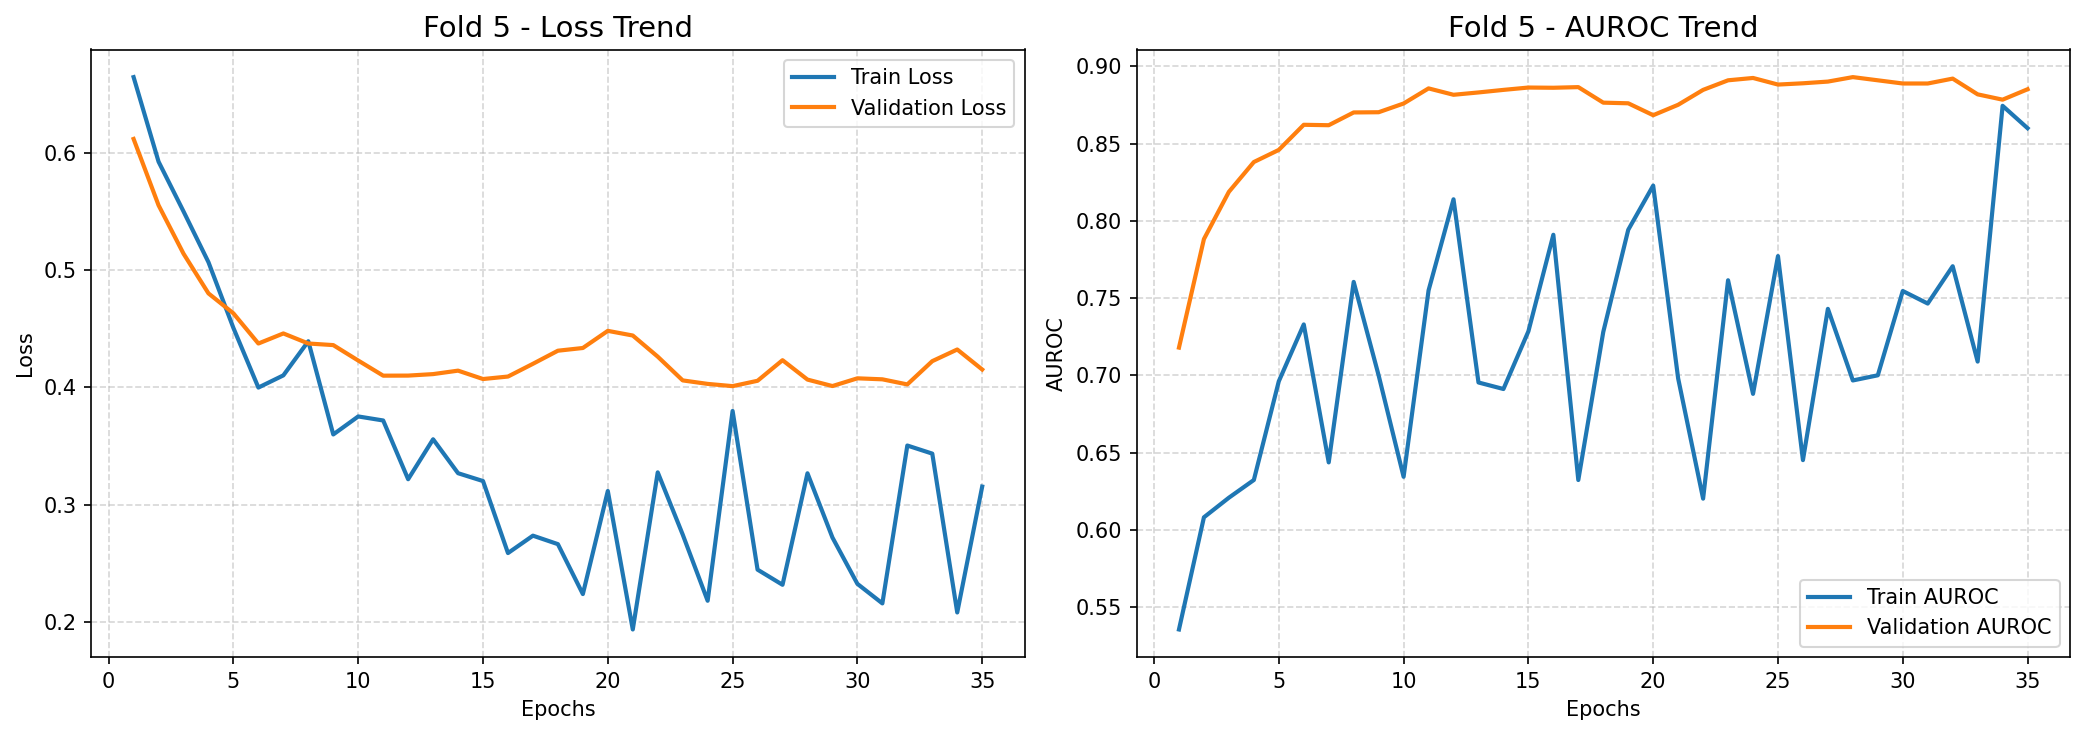

추론 완료! submission_strategy_D2.csv 생성됨.


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import copy  
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

K_FOLDS = 5
EPOCHS = 50
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['label'].values 

# 테스트 데이터 로더 준비
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_preds_ensemble = np.zeros(len(test_dataset))

print(f"[{DEVICE}] 전략 D: 통합 앙상블(AUROC 기반 조기종료) 시작...")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, all_labels)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    train_loader = DataLoader(SolarPanelDataset(fold_train_df, train_img_dir, transform=train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SolarPanelDataset(fold_val_df, train_img_dir, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False)
    
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    patience, counter = 7, 0
    best_val_auroc = 0.0 # Loss가 아닌 AUROC 기준이므로 0.0으로 시작
    best_model_wts = copy.deepcopy(model.state_dict())
    
    # --- [추가] 폴드별 메트릭 기록을 위한 히스토리 초기화 ---
    fold_history = {
        'train_loss': [],
        'val_loss': [],
        'train_auroc': [],
        'val_auroc': []
    }
    
    for epoch in range(EPOCHS):
        # ---------- 1. Train Phase ----------
        model.train()
        running_train_loss = 0.0
        train_preds, train_targets = [], []
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
            
            # [추가] Train AUROC용 데이터 수집
            with torch.no_grad():
                probs = torch.sigmoid(outputs)
                train_preds.extend(probs.cpu().view(-1).numpy())
                mix_target = lam * labels + (1 - lam) * labels[torch.randperm(labels.size()[0]).to(DEVICE)]
                train_targets.extend(mix_target.cpu().view(-1).numpy())
                
        scheduler.step()
        epoch_train_loss = running_train_loss / len(train_loader)
        
        try:
            epoch_train_auroc = roc_auc_score((np.array(train_targets) > 0.5).astype(int), train_preds)
        except ValueError:
            epoch_train_auroc = 0.5
        
        # ---------- 2. Validation Phase ----------
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images).squeeze(-1)
                
                # [추가] 검증 손실(Loss) 계산 루프 반영
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
                val_targets.extend(labels.cpu().view(-1).numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader)
        
        try:
            epoch_val_auroc = roc_auc_score(val_targets, val_preds)
        except ValueError:
            epoch_val_auroc = 0.5
            
        # --- [추가] 히스토리에 수치 누적 ---
        fold_history['train_loss'].append(epoch_train_loss)
        fold_history['val_loss'].append(epoch_val_loss)
        fold_history['train_auroc'].append(epoch_train_auroc)
        fold_history['val_auroc'].append(epoch_val_auroc)
        
        # [수정] 모든 메트릭을 출력하도록 변경
        print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
              f"Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
        
        # ---------- 3. Early Stopping Check (AUROC 기준 최고점 돌파 판단) ----------
        if epoch_val_auroc > best_val_auroc:
            print(f"  ▶ Val AUROC가 개선되었습니다! ({best_val_auroc:.4f} ➡️ {epoch_val_auroc:.4f}). 모델 가중치를 저장합니다.")
            best_val_auroc = epoch_val_auroc
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"⚠️ Fold {fold+1} Early Stopping 발동 (AUROC 개선 없음)")
                break
                
    # --- [추가] 폴드 직후 대시보드(Loss & AUROC) 그리기 ---
    epochs_range = range(1, len(fold_history['train_loss']) + 1)
    plt.figure(figsize=(14, 5), dpi=150)
    
    # 1. Loss 추이 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, fold_history['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(epochs_range, fold_history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title(f'Fold {fold+1} - Loss Trend', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 2. AUROC 추이 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, fold_history['train_auroc'], label='Train AUROC', linewidth=2)
    plt.plot(epochs_range, fold_history['val_auroc'], label='Validation AUROC', linewidth=2)
    plt.title(f'Fold {fold+1} - AUROC Trend', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('AUROC')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(f'strategy_d_fold_{fold+1}_curves.png', bbox_inches='tight')
    plt.show()

    # ---------- 4. Best Model 복원 및 Test Fold 추론 ----------
    model.load_state_dict(best_model_wts)
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
            if probs.ndim == 0: probs = [probs.item()]
            fold_preds.extend(probs)
    test_preds_ensemble += np.array(fold_preds)

test_preds_ensemble /= K_FOLDS
pd.DataFrame({'id': sub_df['id'], 'dusty_prob': test_preds_ensemble}).to_csv(os.path.join(path, 'submission_strategy_D2_Plot.csv'), index=False)
print("추론 완료! submission_strategy_D2.csv 생성됨.")

[cuda] 전략 B: 5-Fold 교차 검증 앙상블 (ConvNeXt-Nano)을 시작합니다...

========== Fold 1/5 ==========
Epoch 1 - Train Loss: 0.6295 | Val Loss: 0.6941 | Train AUROC: 0.6091 | Val AUROC: 0.7597
Epoch 2 - Train Loss: 0.5967 | Val Loss: 0.5268 | Train AUROC: 0.6192 | Val AUROC: 0.8075
Epoch 3 - Train Loss: 0.5072 | Val Loss: 0.5011 | Train AUROC: 0.6536 | Val AUROC: 0.8312
Epoch 4 - Train Loss: 0.4593 | Val Loss: 0.4938 | Train AUROC: 0.7204 | Val AUROC: 0.8425
Epoch 5 - Train Loss: 0.4179 | Val Loss: 0.4464 | Train AUROC: 0.6917 | Val AUROC: 0.8704
Epoch 6 - Train Loss: 0.3824 | Val Loss: 0.5553 | Train AUROC: 0.7225 | Val AUROC: 0.8412
Epoch 7 - Train Loss: 0.4225 | Val Loss: 0.4598 | Train AUROC: 0.6765 | Val AUROC: 0.8647
Epoch 8 - Train Loss: 0.3807 | Val Loss: 0.4948 | Train AUROC: 0.5882 | Val AUROC: 0.8526
Epoch 9 - Train Loss: 0.3375 | Val Loss: 0.6094 | Train AUROC: 0.8113 | Val AUROC: 0.8566
Epoch 10 - Train Loss: 0.3449 | Val Loss: 0.5965 | Train AUROC: 0.7380 | Val AUROC: 0.8351
Epoch 11 - 

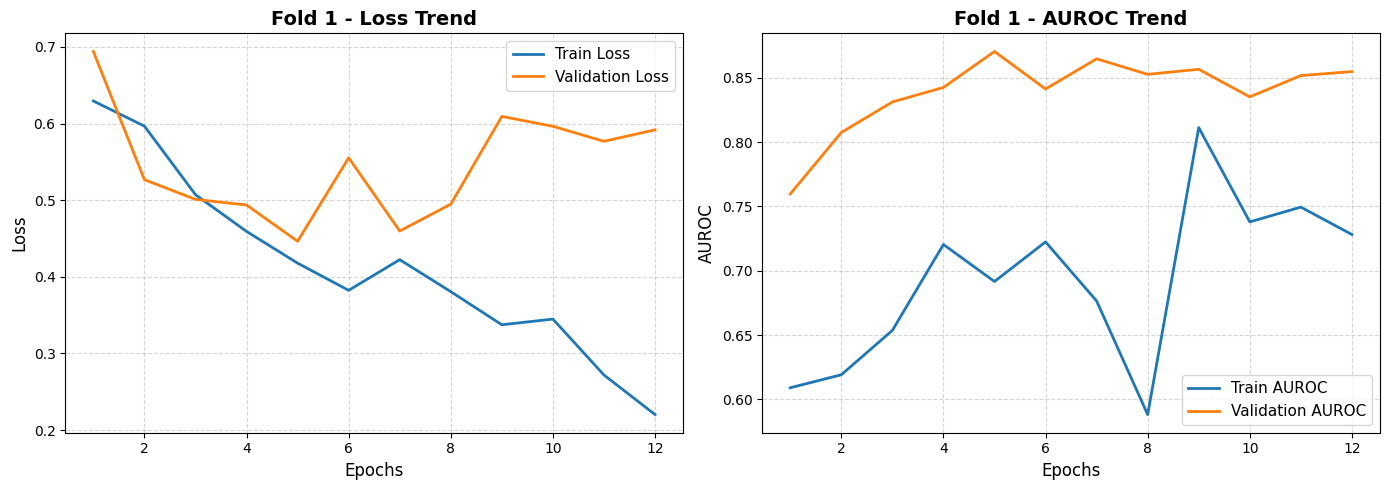

✅ Fold 1 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_1_trend.png


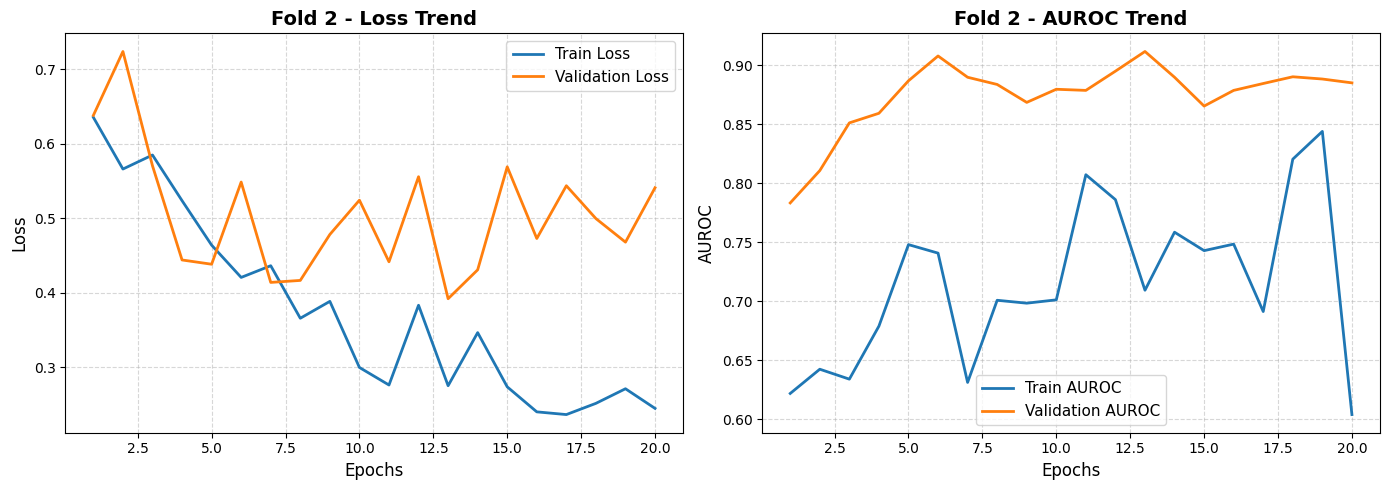

✅ Fold 2 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_2_trend.png


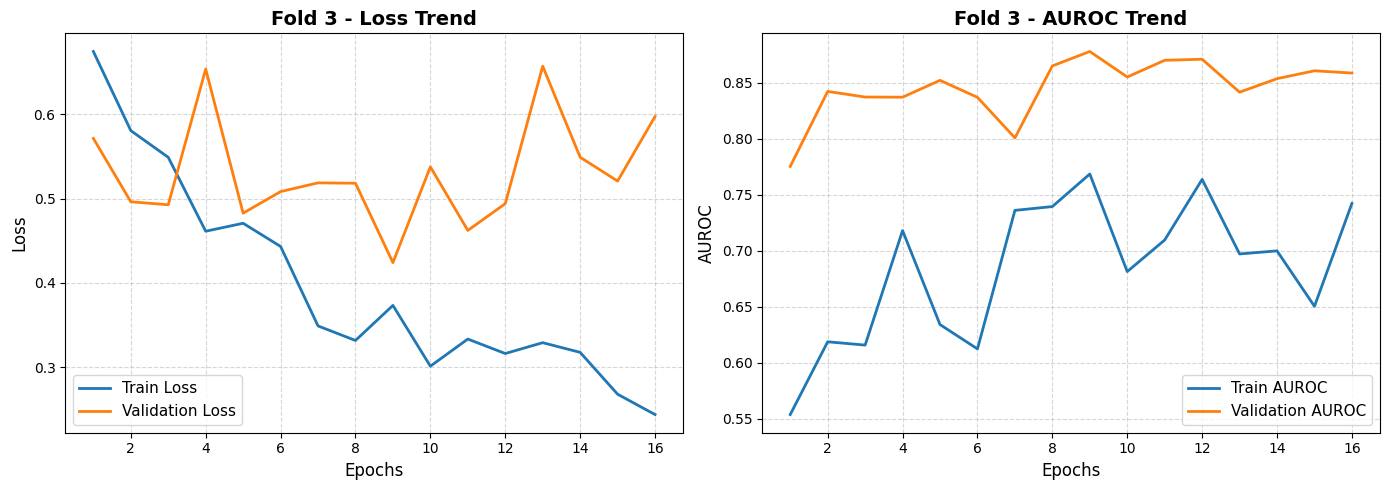

✅ Fold 3 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_3_trend.png


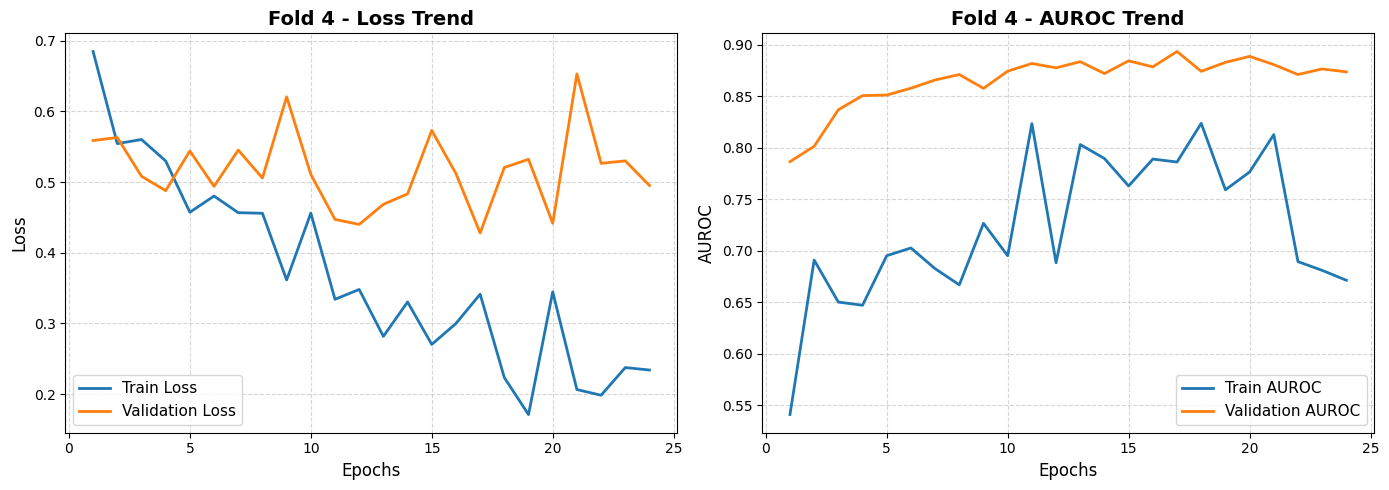

✅ Fold 4 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_4_trend.png


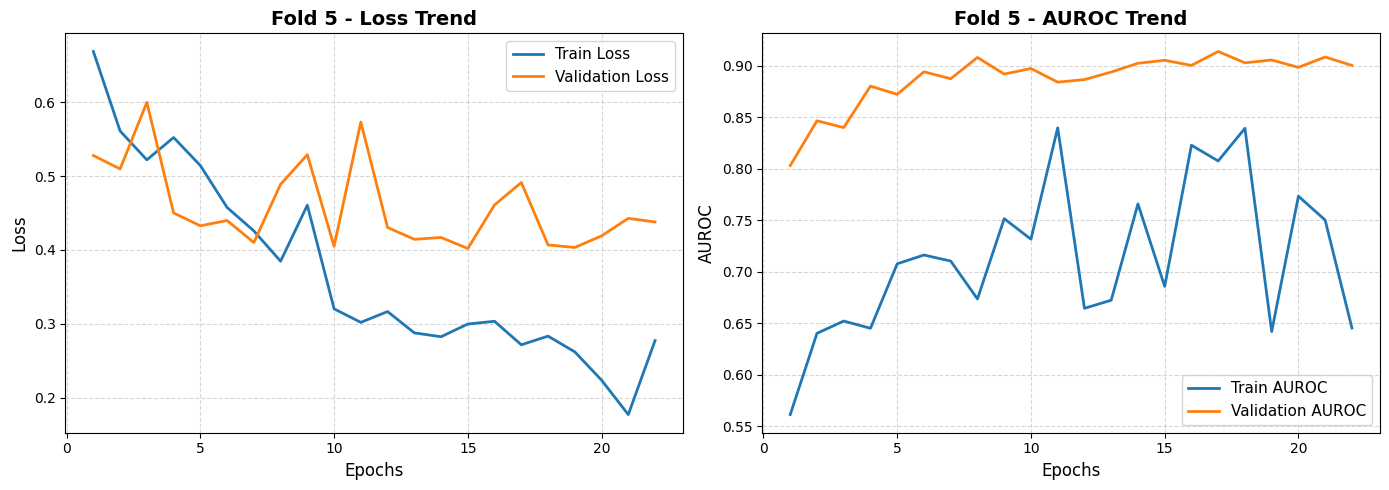

✅ Fold 5 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_5_trend.png


In [18]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import timm  # ConvNeXt 모델 활용을 위해 필요
import matplotlib.pyplot as plt  # 🌟 그래프 시각화를 위해 추가

# 1. ConvNeXt 모델 정의 (이진 분류용)
class ConvNeXtClassifier(nn.Module):
    def __init__(self, model_name='convnext_nano', pretrained=True, drop_rate=0.3):
        super(ConvNeXtClassifier, self).__init__()
        self.model = timm.create_model(
            model_name, 
            pretrained=pretrained, 
            num_classes=0, 
            drop_rate=drop_rate
        )
        num_features = self.model.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(drop_rate),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        features = self.model(x)
        logits = self.head(features)
        return logits

# ==========================================
# 전략 B 변경안: 5-Fold 앙상블 (ConvNeXt-Nano 적용) + 수치 추출 및 시각화
# ==========================================

K_FOLDS = 5
EPOCHS = 50
LEARNING_RATE = 5e-5  
WEIGHT_DECAY = 1e-4

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['label'].values 

# 테스트 데이터 로더 준비
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_preds_ensemble = np.zeros(len(test_dataset))

# 🌟 모든 Fold의 수치를 저장할 메인 딕셔너리 생성
fold_histories = {}

print(f"[{DEVICE}] 전략 B: 5-Fold 교차 검증 앙상블 (ConvNeXt-Nano)을 시작합니다...")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, all_labels)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")
    
    # 현재 Fold의 기록을 담을 리스트 초기화
    history = {'train_loss': [], 'val_loss': [], 'train_auroc': [], 'val_auroc': []}
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    train_loader = DataLoader(SolarPanelDataset(fold_train_df, train_img_dir, transform=train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SolarPanelDataset(fold_val_df, train_img_dir, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False)
    
    model = ConvNeXtClassifier(model_name='convnext_nano', pretrained=True, drop_rate=0.3)
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    patience, counter = 7, 0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        # ----------------- Training -----------------
        model.train()
        running_train_loss = 0.0
        train_preds, train_targets = [], []
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            # Train AUROC 계산용 (Mixup이 들어갔으므로 원래 라벨 targets_a 기준으로 경향성만 트래킹)
            train_preds.extend(torch.sigmoid(outputs).detach().cpu().view(-1).numpy())
            train_targets.extend(targets_a.cpu().view(-1).numpy())
            
        scheduler.step()
        
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_auroc = roc_auc_score(train_targets, train_preds)
        
        # ----------------- Validation -----------------
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images).squeeze(-1)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
                val_targets.extend(labels.cpu().view(-1).numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
        
        print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
        
        # 🌟 리스트에 에폭별 수치 추가
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_auroc'].append(epoch_train_auroc)
        history['val_auroc'].append(epoch_val_auroc)
        
        # Early Stopping Check
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("⚠️ Early Stopping 발동")
                break
                
    # 폴드 종료 후 메인 딕셔너리에 저장
    fold_histories[fold] = history
                
    # ----------------- Fold Inference -----------------
    model.load_state_dict(best_model_wts)
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
            if probs.ndim == 0: 
                probs = [probs.item()]
            fold_preds.extend(probs)
    test_preds_ensemble += np.array(fold_preds)

# 5개 Fold 예측 평균내기 및 결과 저장
test_preds_ensemble /= K_FOLDS
pd.DataFrame({'id': sub_df['id'], 'dusty_prob': test_preds_ensemble}).to_csv(os.path.join(path, 'submission_strategy_B_convext.csv'), index=False)
print("추론 완료! submission_strategy_B2.csv 생성됨.")


# =================================================================
# 🌟 3. 수치 데이터 프레임 변환 및 그래프 저장 파트
# =================================================================
print("\n📊 폴드별 학습 결과 수치 및 그래프 추출을 시작합니다...")

# 각 폴드별 기록을 CSV 파일로도 개별 보관하고 싶다면 아래 주석을 해제하세요.
# for fold in range(K_FOLDS):
#     pd.DataFrame(fold_histories[fold]).to_csv(os.path.join(path, f'fold_{fold+1}_history.csv'), index=False)

# 각 Fold마다 독립된 그래프를 생성하여 저장합니다.
for fold in range(K_FOLDS):
    h = fold_histories[fold]
    epochs_range = range(1, len(h['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Loss Trend 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - Loss Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    # 2. AUROC Trend 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h['train_auroc'], label='Train AUROC', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_auroc'], label='Validation AUROC', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - AUROC Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('AUROC', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    
    # 이미지 파일 저장 및 출력
    plot_path = os.path.join(path, f'fold_{fold+1}_trend.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"✅ Fold {fold+1} 그래프 저장 완료: {plot_path}")

In [22]:
import timm
# 내 timm에서 지원하는 maxvit 모델 리스트 출력
print([m for m in timm.list_models() if 'maxvit' in m])

['maxvit_base_tf_224', 'maxvit_base_tf_384', 'maxvit_base_tf_512', 'maxvit_large_tf_224', 'maxvit_large_tf_384', 'maxvit_large_tf_512', 'maxvit_nano_rw_256', 'maxvit_pico_rw_256', 'maxvit_rmlp_base_rw_224', 'maxvit_rmlp_base_rw_384', 'maxvit_rmlp_nano_rw_256', 'maxvit_rmlp_pico_rw_256', 'maxvit_rmlp_small_rw_224', 'maxvit_rmlp_small_rw_256', 'maxvit_rmlp_tiny_rw_256', 'maxvit_small_tf_224', 'maxvit_small_tf_384', 'maxvit_small_tf_512', 'maxvit_tiny_pm_256', 'maxvit_tiny_rw_224', 'maxvit_tiny_rw_256', 'maxvit_tiny_tf_224', 'maxvit_tiny_tf_384', 'maxvit_tiny_tf_512', 'maxvit_xlarge_tf_224', 'maxvit_xlarge_tf_384', 'maxvit_xlarge_tf_512']


[cuda] 전략 B: 5-Fold 교차 검증 앙상블 (MaxViT-Nano)을 시작합니다...

========== Fold 1/5 ==========


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

c:\Users\H11\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\H11\.cache\huggingface\hub\models--timm--maxvit_tiny_tf_224.in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Epoch 1 - Train Loss: 0.6745 | Val Loss: 0.6163 | Train AUROC: 0.5380 | Val AUROC: 0.6866
Epoch 2 - Train Loss: 0.6119 | Val Loss: 0.5776 | Train AUROC: 0.5936 | Val AUROC: 0.7437
Epoch 3 - Train Loss: 0.5475 | Val Loss: 0.5419 | Train AUROC: 0.6456 | Val AUROC: 0.7881
Epoch 4 - Train Loss: 0.5469 | Val Loss: 0.5306 | Train AUROC: 0.6975 | Val AUROC: 0.8110
Epoch 5 - Train Loss: 0.4918 | Val Loss: 0.5221 | Train AUROC: 0.6781 | Val AUROC: 0.8155
Epoch 6 - Train Loss: 0.4969 | Val Loss: 0.4985 | Train AUROC: 0.7302 | Val AUROC: 0.8393
Epoch 7 - Train Loss: 0.3886 | Val Loss: 0.5261 | Train AUROC: 0.6592 | Val AUROC: 0.8430
Epoch 8 - Train Loss: 0.3862 | Val Loss: 0.5119 | Train AUROC: 0.7352 | Val AUROC: 0.8429
Epoch 9 - Train Loss: 0.3575 | Val Loss: 0.5042 | Train AUROC: 0.6837 | Val AUROC: 0.8563
Epoch 10 - Train Loss: 0.3749 | Val Loss: 0.5323 | Train AUROC: 0.6503 | Val AUROC: 0.8493
Epoch 11 - Train Loss: 0.3163 | Val Loss: 0.5312 | Train AUROC: 0.7361 | Val AUROC: 0.8488
Epoch 12

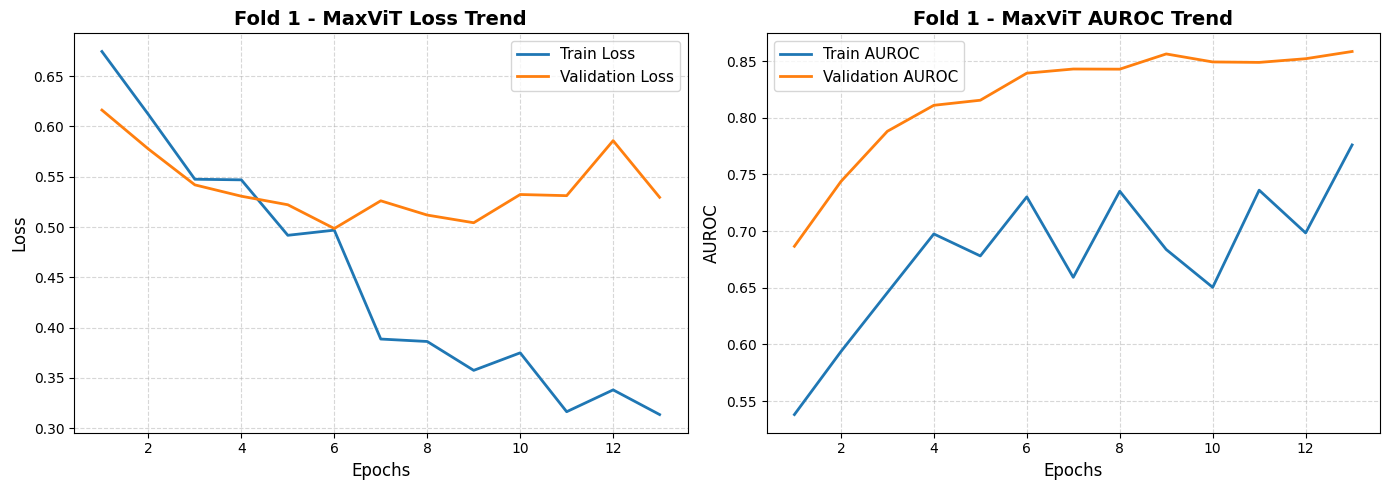

✅ Fold 1 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_1_maxvit_trend.png


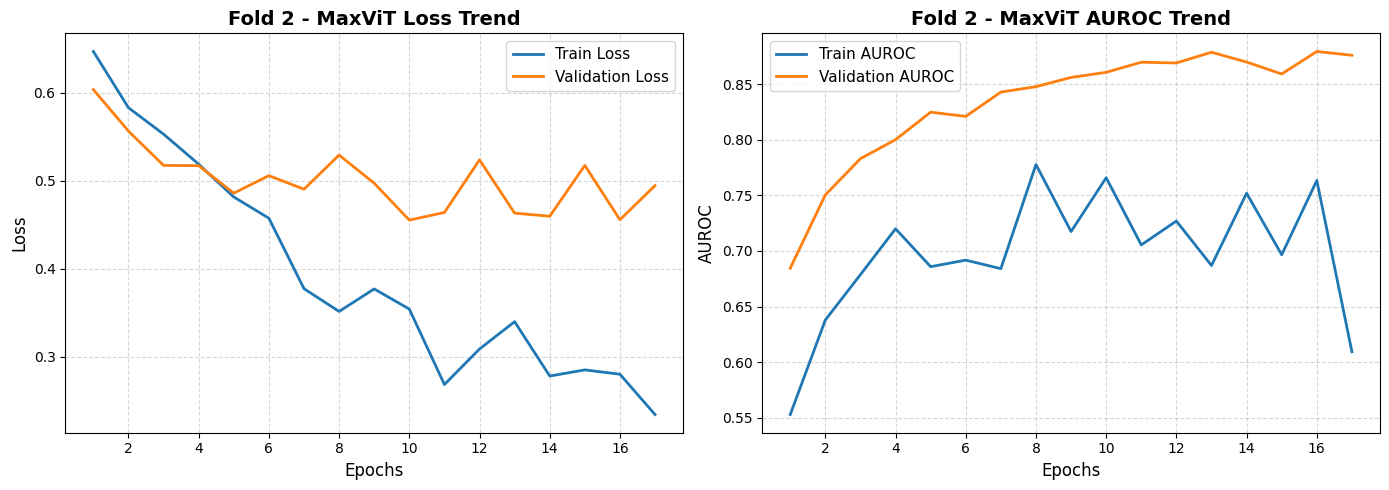

✅ Fold 2 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_2_maxvit_trend.png


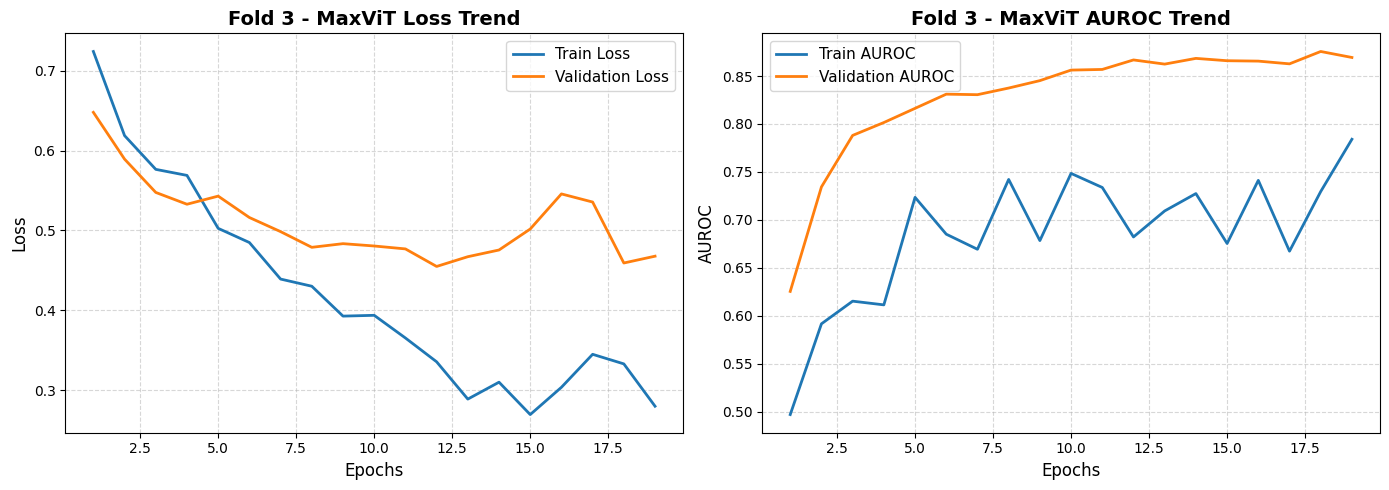

✅ Fold 3 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_3_maxvit_trend.png


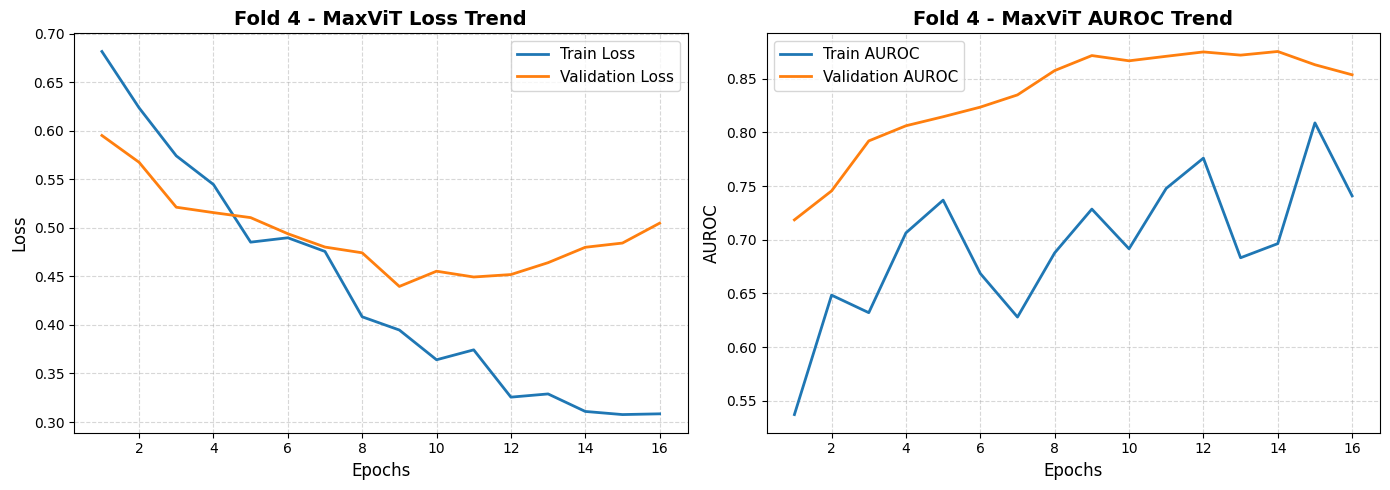

✅ Fold 4 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_4_maxvit_trend.png


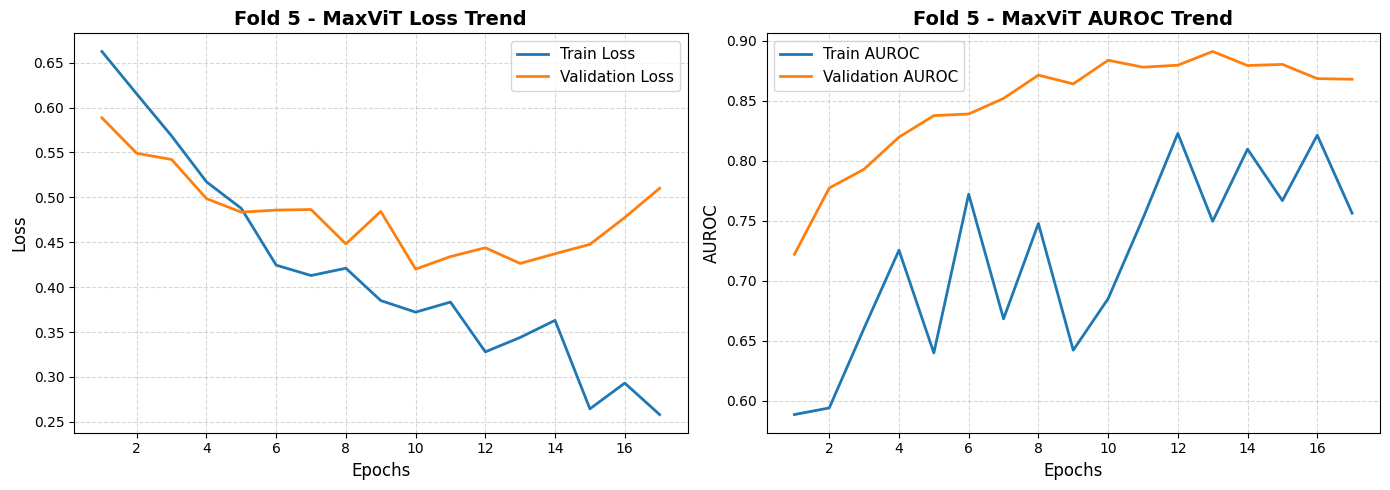

✅ Fold 5 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_5_maxvit_trend.png


In [23]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import timm  # MaxViT 모델 활용을 위해 필요
import matplotlib.pyplot as plt  # 그래프 시각화를 위해 추가

# 1. MaxViT 모델 정의 (이진 분류용)
class MaxViTClassifier(nn.Module):
    def __init__(self, model_name='maxvit_tiny_tf_224', pretrained=True, drop_rate=0.3):
        super(MaxViTClassifier, self).__init__()
        # timm 백본 로드 (마지막 Classifier FC 레이어 제외)
        self.model = timm.create_model(
            model_name, 
            pretrained=pretrained, 
            num_classes=0, 
            drop_rate=drop_rate
        )
        num_features = self.model.num_features
        # 이진 분류용 최종 헤드 구성
        self.head = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(drop_rate),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        features = self.model(x)
        logits = self.head(features)
        return logits

# ==========================================
# 전략 B 변경안: 5-Fold 앙상블 (MaxViT-Nano 적용) + 수치 추출 및 시각화
# ==========================================

K_FOLDS = 5
EPOCHS = 50
LEARNING_RATE = 5e-5  # MaxViT는 Transformer 성격이 있으므로 소규모 데이터셋에선 5e-5 수준이 안전합니다.
WEIGHT_DECAY = 1e-4

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['label'].values 

# 테스트 데이터 로더 준비
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_preds_ensemble = np.zeros(len(test_dataset))

# 모든 Fold의 수치를 저장할 메인 딕셔너리 생성
fold_histories = {}

print(f"[{DEVICE}] 전략 B: 5-Fold 교차 검증 앙상블 (MaxViT-Nano)을 시작합니다...")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, all_labels)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")
    
    # 현재 Fold의 기록을 담을 리스트 초기화
    history = {'train_loss': [], 'val_loss': [], 'train_auroc': [], 'val_auroc': []}
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    train_loader = DataLoader(SolarPanelDataset(fold_train_df, train_img_dir, transform=train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SolarPanelDataset(fold_val_df, train_img_dir, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False)
    
    # 🌟 모델을 MaxViTClassifier로 변경합니다.
    model = MaxViTClassifier(model_name='maxvit_tiny_tf_224', pretrained=True, drop_rate=0.3)
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    patience, counter = 7, 0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        # ----------------- Training -----------------
        model.train()
        running_train_loss = 0.0
        train_preds, train_targets = [], []
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            # Train AUROC 계산용 (Mixup targets_a 기준 트래킹)
            train_preds.extend(torch.sigmoid(outputs).detach().cpu().view(-1).numpy())
            train_targets.extend(targets_a.cpu().view(-1).numpy())
            
        scheduler.step()
        
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_auroc = roc_auc_score(train_targets, train_preds)
        
        # ----------------- Validation -----------------
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images).squeeze(-1)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
                val_targets.extend(labels.cpu().view(-1).numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
        
        print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
        
        # 리스트에 에폭별 수치 추가
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_auroc'].append(epoch_train_auroc)
        history['val_auroc'].append(epoch_val_auroc)
        
        # Early Stopping Check
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("⚠️ Early Stopping 발동")
                break
                
    # 폴드 종료 후 메인 딕셔너리에 저장
    fold_histories[fold] = history
                
    # ----------------- Fold Inference -----------------
    model.load_state_dict(best_model_wts)
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
            if probs.ndim == 0: 
                probs = [probs.item()]
            fold_preds.extend(probs)
    test_preds_ensemble += np.array(fold_preds)

# 5개 Fold 예측 평균내기 및 결과 저장
test_preds_ensemble /= K_FOLDS
# 🌟 출력 파일명을 MaxViT에 맞게 직관적으로 변경했습니다.
pd.DataFrame({'id': sub_df['id'], 'dusty_prob': test_preds_ensemble}).to_csv(os.path.join(path, 'submission_strategy_B_maxvit.csv'), index=False)
print("추론 완료! submission_strategy_B_maxvit.csv 생성됨.")


# =================================================================
# 3. 수치 데이터 프레임 변환 및 그래프 저장 파트
# =================================================================
print("\n📊 폴드별 학습 결과 수치 및 그래프 추출을 시작합니다...")

# 각 Fold마다 독립된 그래프를 생성하여 저장합니다.
for fold in range(K_FOLDS):
    h = fold_histories[fold]
    epochs_range = range(1, len(h['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Loss Trend 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - MaxViT Loss Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    # 2. AUROC Trend 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h['train_auroc'], label='Train AUROC', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_auroc'], label='Validation AUROC', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - MaxViT AUROC Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('AUROC', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    
    # 이미지 파일 저장 및 출력명 변경
    plot_path = os.path.join(path, f'fold_{fold+1}_maxvit_trend.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"✅ Fold {fold+1} 그래프 저장 완료: {plot_path}")

[cuda] 전략 B: 5-Fold 교차 검증 앙상블 (MaxViT-Nano)을 시작합니다...

========== Fold 1/5 ==========


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

c:\Users\H11\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\H11\.cache\huggingface\hub\models--timm--coatnet_0_rw_224.sw_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Epoch 1 - Train Loss: 0.6736 | Val Loss: 0.5599 | Train AUROC: 0.5964 | Val AUROC: 0.7730
Epoch 2 - Train Loss: 0.5730 | Val Loss: 0.5285 | Train AUROC: 0.6267 | Val AUROC: 0.8045
Epoch 3 - Train Loss: 0.5147 | Val Loss: 0.5739 | Train AUROC: 0.7034 | Val AUROC: 0.8137
Epoch 4 - Train Loss: 0.5072 | Val Loss: 0.5652 | Train AUROC: 0.6480 | Val AUROC: 0.8379
Epoch 5 - Train Loss: 0.4651 | Val Loss: 0.5424 | Train AUROC: 0.6596 | Val AUROC: 0.8387
Epoch 6 - Train Loss: 0.4153 | Val Loss: 0.5809 | Train AUROC: 0.7094 | Val AUROC: 0.8380
Epoch 7 - Train Loss: 0.3794 | Val Loss: 0.5527 | Train AUROC: 0.6261 | Val AUROC: 0.8498
Epoch 8 - Train Loss: 0.3640 | Val Loss: 0.5760 | Train AUROC: 0.6973 | Val AUROC: 0.8506
Epoch 9 - Train Loss: 0.3288 | Val Loss: 0.6013 | Train AUROC: 0.7112 | Val AUROC: 0.8366
⚠️ Early Stopping 발동

========== Fold 2/5 ==========
Epoch 1 - Train Loss: 0.6660 | Val Loss: 0.5996 | Train AUROC: 0.5445 | Val AUROC: 0.7408
Epoch 2 - Train Loss: 0.5745 | Val Loss: 0.5084

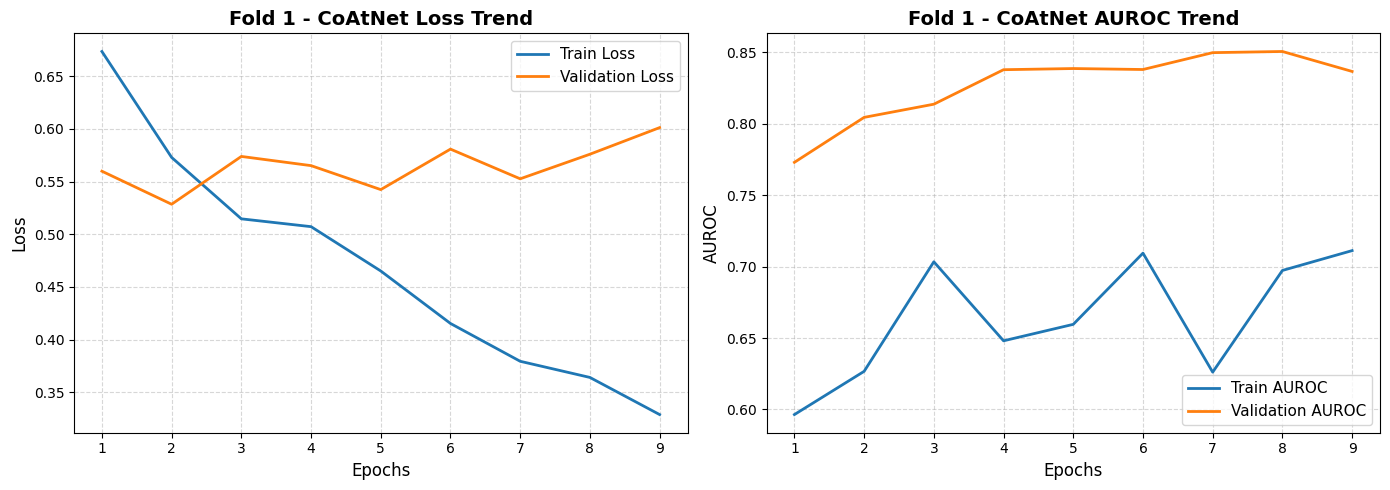

✅ Fold 1 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_1_CoAtNet_trend.png


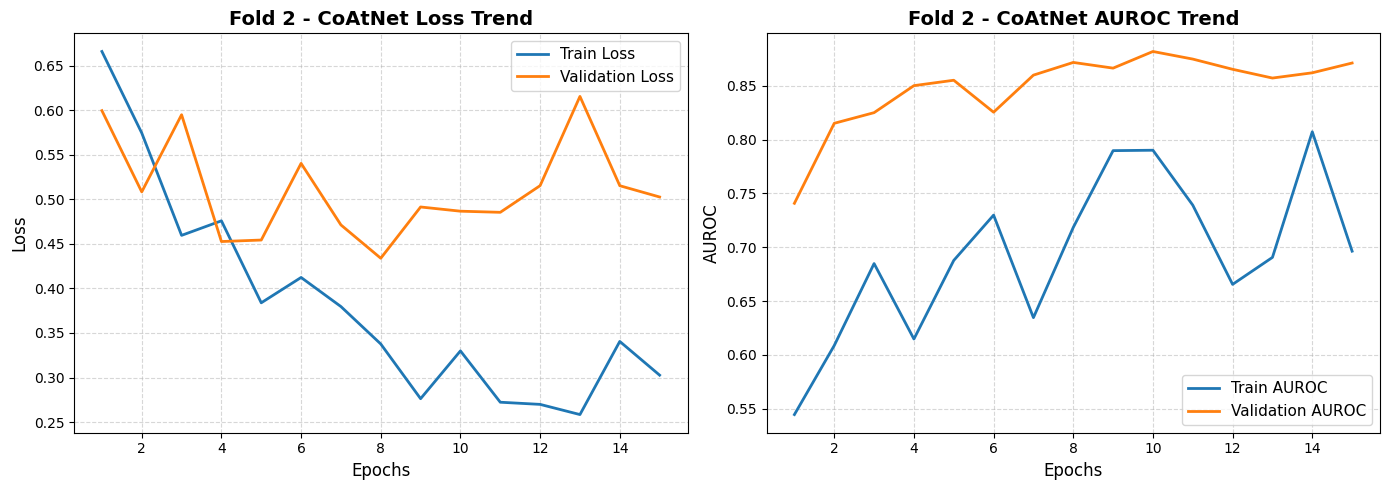

✅ Fold 2 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_2_CoAtNet_trend.png


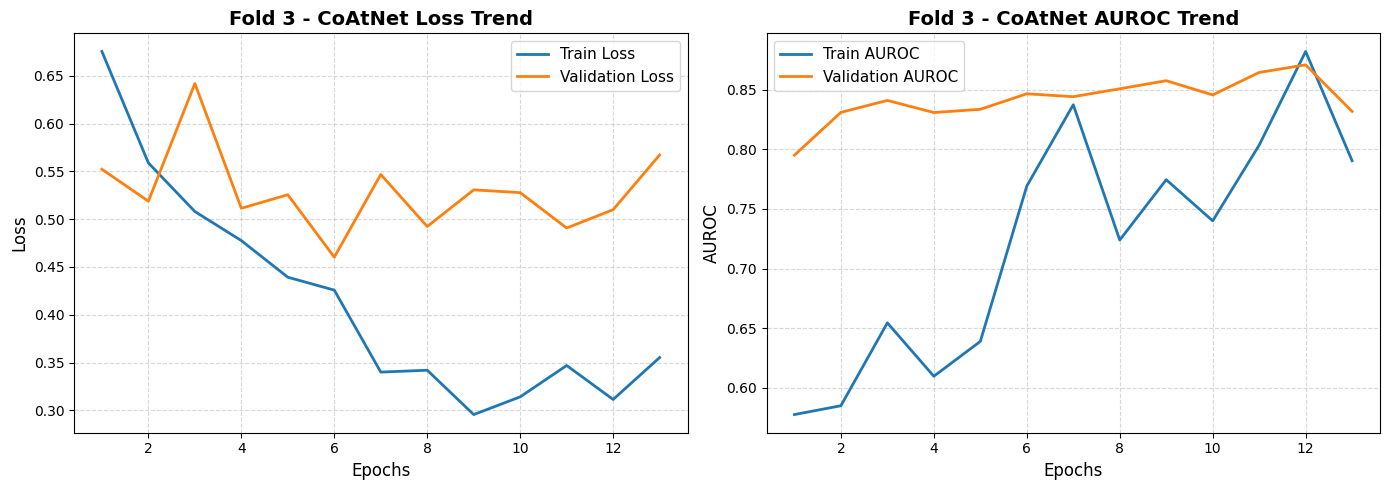

✅ Fold 3 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_3_CoAtNet_trend.png


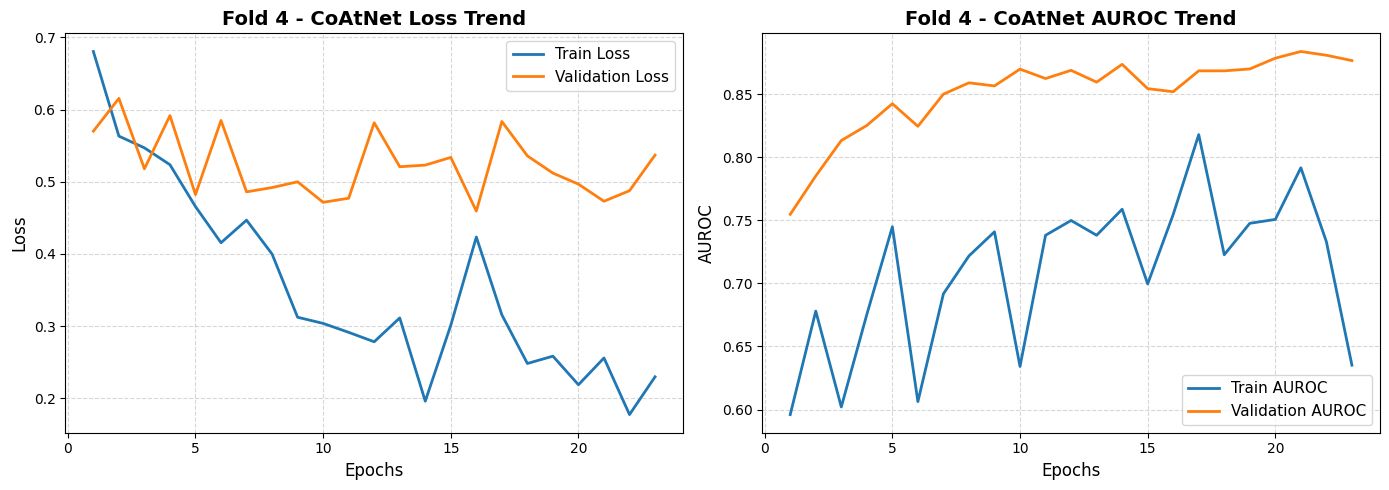

✅ Fold 4 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_4_CoAtNet_trend.png


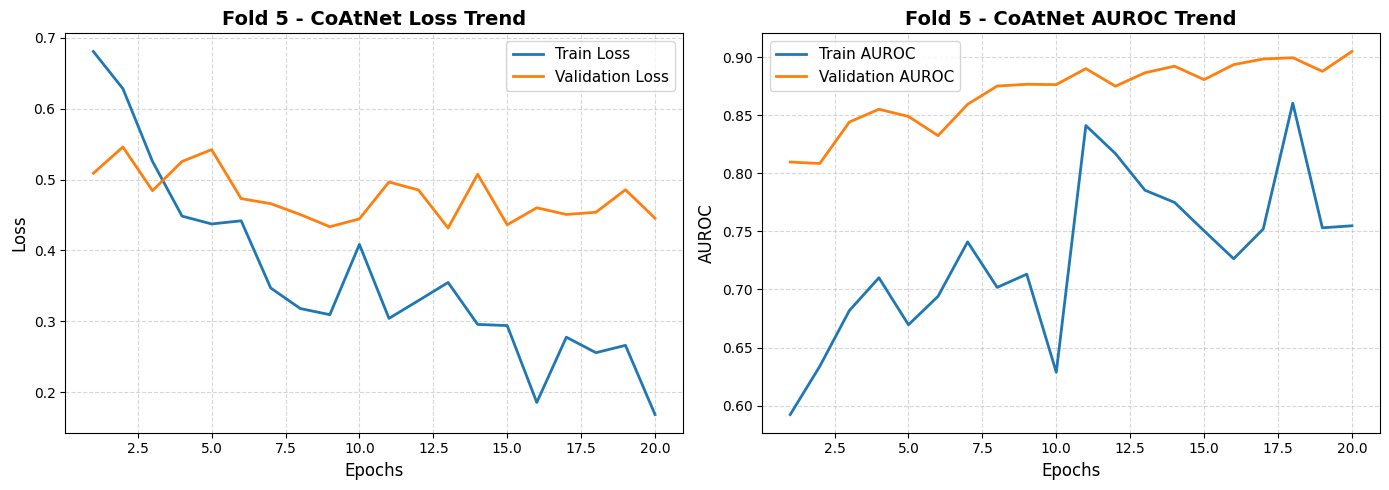

✅ Fold 5 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_5_CoAtNet_trend.png


In [25]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import timm  # MaxViT 모델 활용을 위해 필요
import matplotlib.pyplot as plt  # 그래프 시각화를 위해 추가

# 1. MaxViT 모델 정의 (이진 분류용)
class CoAtNetClassifier(nn.Module):
    def __init__(self, model_name='coatnet_0_rw_224', pretrained=True, drop_rate=0.3):
        super(CoAtNetClassifier, self).__init__()
        # timm 백본 로드 (마지막 Classifier FC 레이어 제외)
        self.model = timm.create_model(
            model_name, 
            pretrained=pretrained, 
            num_classes=0, 
            drop_rate=drop_rate
        )
        num_features = self.model.num_features
        # 이진 분류용 최종 헤드 구성
        self.head = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(drop_rate),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        features = self.model(x)
        logits = self.head(features)
        return logits

# ==========================================
# 전략 B 변경안: 5-Fold 앙상블 (MaxViT-Nano 적용) + 수치 추출 및 시각화
# ==========================================

K_FOLDS = 5
EPOCHS = 50
LEARNING_RATE = 5e-5  # MaxViT는 Transformer 성격이 있으므로 소규모 데이터셋에선 5e-5 수준이 안전합니다.
WEIGHT_DECAY = 1e-4

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['label'].values 

# 테스트 데이터 로더 준비
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_preds_ensemble = np.zeros(len(test_dataset))

# 모든 Fold의 수치를 저장할 메인 딕셔너리 생성
fold_histories = {}

print(f"[{DEVICE}] 전략 B: 5-Fold 교차 검증 앙상블 (MaxViT-Nano)을 시작합니다...")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, all_labels)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")
    
    # 현재 Fold의 기록을 담을 리스트 초기화
    history = {'train_loss': [], 'val_loss': [], 'train_auroc': [], 'val_auroc': []}
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    train_loader = DataLoader(SolarPanelDataset(fold_train_df, train_img_dir, transform=train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SolarPanelDataset(fold_val_df, train_img_dir, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False)
    
    # 🌟 모델을 CoAtNetClassifier 변경합니다.
    model = CoAtNetClassifier(model_name='coatnet_0_rw_224', pretrained=True, drop_rate=0.3)
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    patience, counter = 7, 0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        # ----------------- Training -----------------
        model.train()
        running_train_loss = 0.0
        train_preds, train_targets = [], []
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            # Train AUROC 계산용 (Mixup targets_a 기준 트래킹)
            train_preds.extend(torch.sigmoid(outputs).detach().cpu().view(-1).numpy())
            train_targets.extend(targets_a.cpu().view(-1).numpy())
            
        scheduler.step()
        
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_auroc = roc_auc_score(train_targets, train_preds)
        
        # ----------------- Validation -----------------
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images).squeeze(-1)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
                val_targets.extend(labels.cpu().view(-1).numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
        
        print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
        
        # 리스트에 에폭별 수치 추가
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_auroc'].append(epoch_train_auroc)
        history['val_auroc'].append(epoch_val_auroc)
        
        # Early Stopping Check
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("⚠️ Early Stopping 발동")
                break
                
    # 폴드 종료 후 메인 딕셔너리에 저장
    fold_histories[fold] = history
                
    # ----------------- Fold Inference -----------------
    model.load_state_dict(best_model_wts)
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
            if probs.ndim == 0: 
                probs = [probs.item()]
            fold_preds.extend(probs)
    test_preds_ensemble += np.array(fold_preds)

# 5개 Fold 예측 평균내기 및 결과 저장
test_preds_ensemble /= K_FOLDS
# 🌟 출력 파일명을 MaxViT에 맞게 직관적으로 변경했습니다.
pd.DataFrame({'id': sub_df['id'], 'dusty_prob': test_preds_ensemble}).to_csv(os.path.join(path, 'submission_strategy_B_CoAtNet.csv'), index=False)
print("추론 완료! submission_strategy_B_CoAtNet.csv 생성됨.")


# =================================================================
# 3. 수치 데이터 프레임 변환 및 그래프 저장 파트
# =================================================================
print("\n📊 폴드별 학습 결과 수치 및 그래프 추출을 시작합니다...")

# 각 Fold마다 독립된 그래프를 생성하여 저장합니다.
for fold in range(K_FOLDS):
    h = fold_histories[fold]
    epochs_range = range(1, len(h['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Loss Trend 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - CoAtNet Loss Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    # 2. AUROC Trend 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h['train_auroc'], label='Train AUROC', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_auroc'], label='Validation AUROC', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - CoAtNet AUROC Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('AUROC', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    
    # 이미지 파일 저장 및 출력명 변경
    plot_path = os.path.join(path, f'fold_{fold+1}_CoAtNet_trend.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"✅ Fold {fold+1} 그래프 저장 완료: {plot_path}")

[cuda] 전략 B: 5-Fold 교차 검증 앙상블 (eva02_tiny_patch14_224-Nano)을 시작합니다...

========== Fold 1/5 ==========
Epoch 1 - Train Loss: 0.7127 | Val Loss: 0.6620 | Train AUROC: 0.4964 | Val AUROC: 0.6722
Epoch 2 - Train Loss: 0.6608 | Val Loss: 0.6167 | Train AUROC: 0.5518 | Val AUROC: 0.6863
Epoch 3 - Train Loss: 0.6341 | Val Loss: 0.5751 | Train AUROC: 0.5261 | Val AUROC: 0.7437
Epoch 4 - Train Loss: 0.5837 | Val Loss: 0.5295 | Train AUROC: 0.6059 | Val AUROC: 0.8157
Epoch 5 - Train Loss: 0.5728 | Val Loss: 0.5246 | Train AUROC: 0.6068 | Val AUROC: 0.8328
Epoch 6 - Train Loss: 0.5167 | Val Loss: 0.5394 | Train AUROC: 0.6873 | Val AUROC: 0.8206
Epoch 7 - Train Loss: 0.4979 | Val Loss: 0.5116 | Train AUROC: 0.6517 | Val AUROC: 0.8345
Epoch 8 - Train Loss: 0.5137 | Val Loss: 0.5126 | Train AUROC: 0.6809 | Val AUROC: 0.8437
Epoch 9 - Train Loss: 0.4372 | Val Loss: 0.5869 | Train AUROC: 0.7195 | Val AUROC: 0.8265
Epoch 10 - Train Loss: 0.5071 | Val Loss: 0.5281 | Train AUROC: 0.6813 | Val AUROC: 0.84

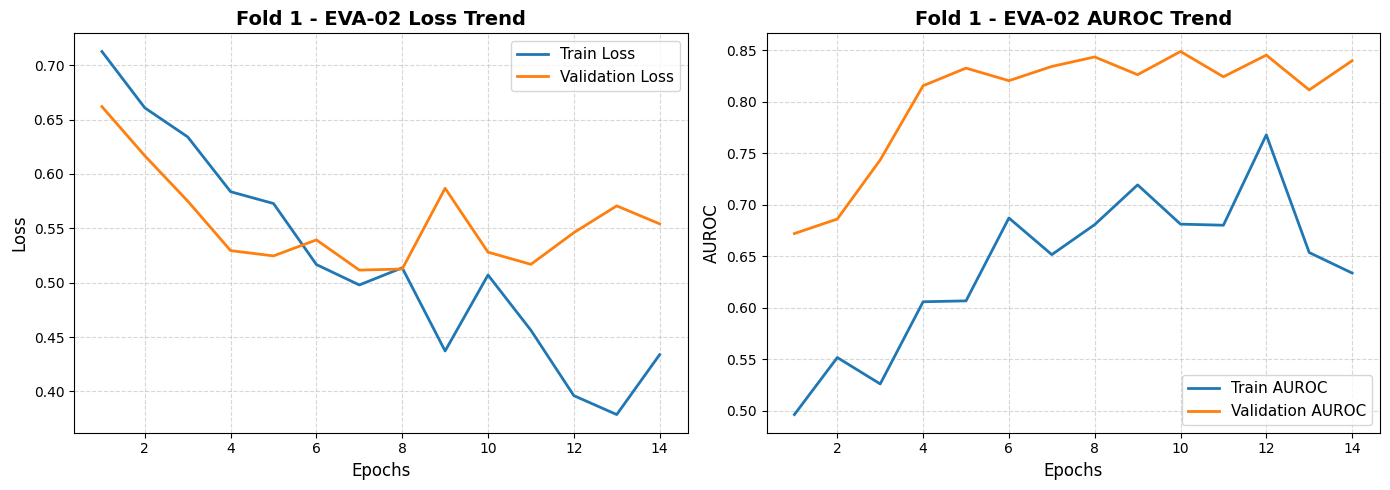

✅ Fold 1 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_1_EVA-02_trend.png


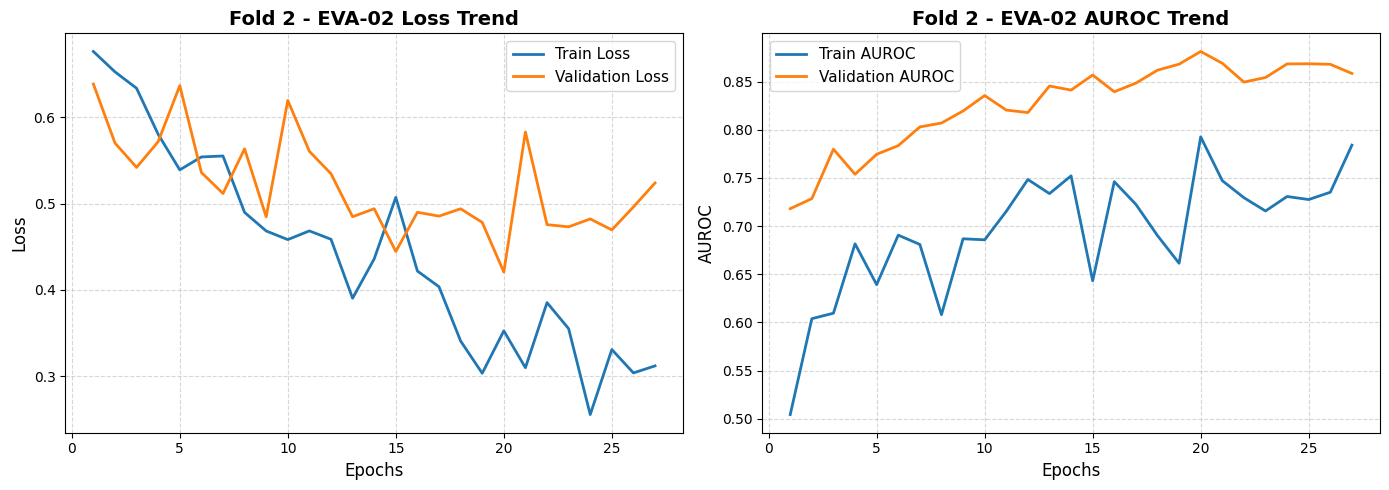

✅ Fold 2 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_2_EVA-02_trend.png


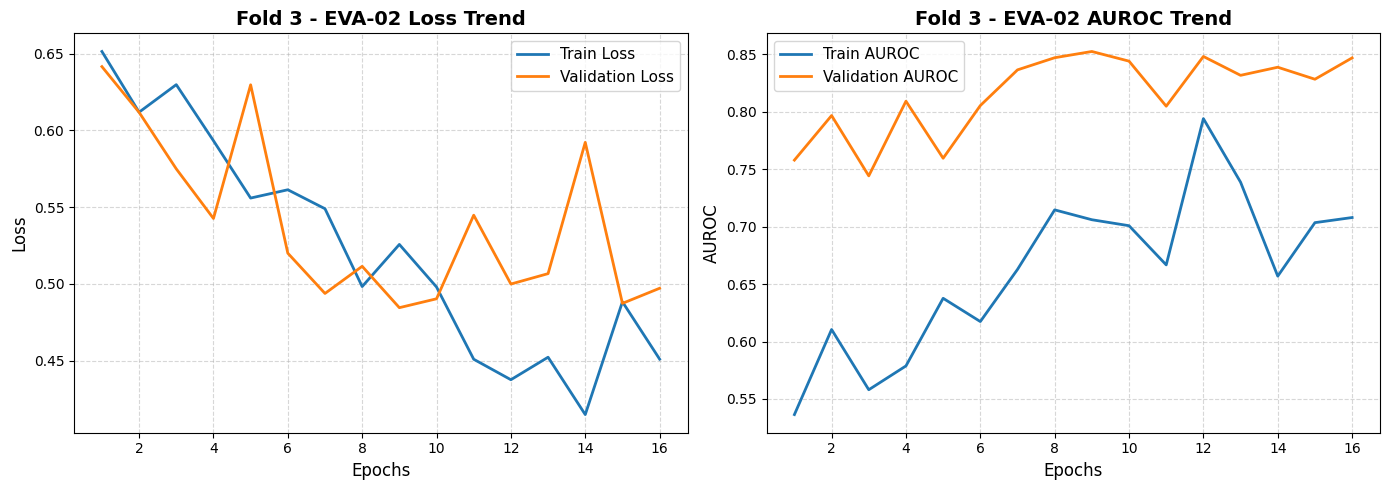

✅ Fold 3 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_3_EVA-02_trend.png


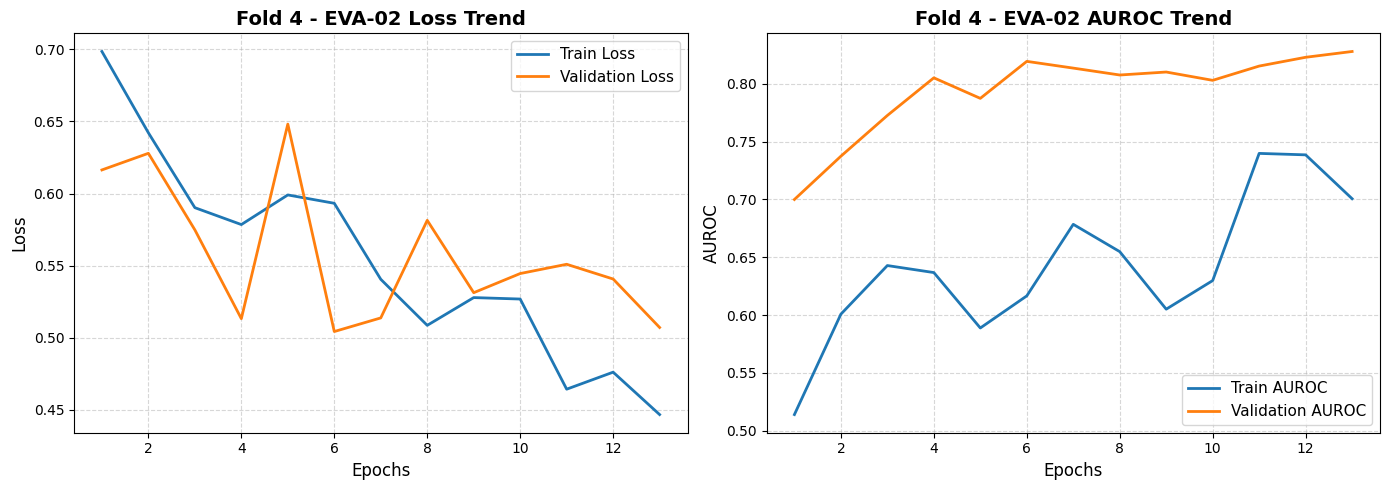

✅ Fold 4 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_4_EVA-02_trend.png


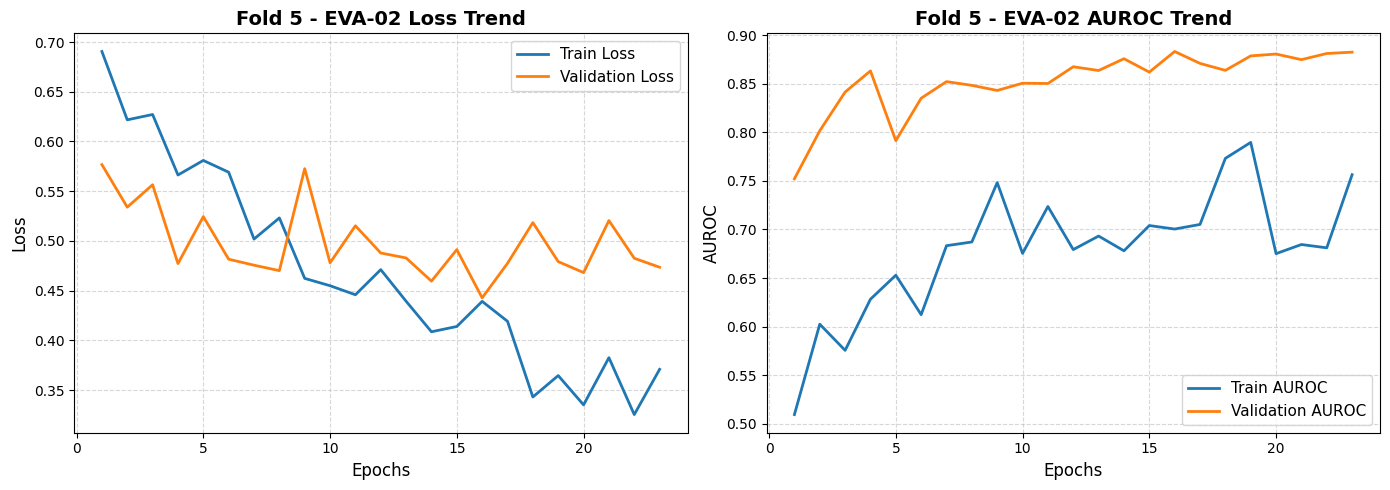

✅ Fold 5 그래프 저장 완료: C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-a\fold_5_EVA-02_trend.png


In [27]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import timm  # eva02_tiny_patch14_224 모델 활용을 위해 필요
import matplotlib.pyplot as plt  # 그래프 시각화를 위해 추가

# 1. eva02_tiny_patch14_224 모델 정의 (이진 분류용)
class EvaClassifier(nn.Module):
    def __init__(self, model_name='eva02_tiny_patch14_224', pretrained=True, drop_rate=0.3):
        super(EvaClassifier, self).__init__()
        # timm 백본 로드 (마지막 Classifier FC 레이어 제외)
        self.model = timm.create_model(
            model_name, 
            pretrained=pretrained, 
            num_classes=0, 
            drop_rate=drop_rate
        )
        num_features = self.model.num_features
        # 이진 분류용 최종 헤드 구성
        self.head = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(drop_rate),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        features = self.model(x)
        logits = self.head(features)
        return logits

# ==========================================
# 전략 B 변경안: 5-Fold 앙상블 (MaxViT-Nano 적용) + 수치 추출 및 시각화
# ==========================================

K_FOLDS = 5
EPOCHS = 50
LEARNING_RATE = 5e-5  # MaxViT는 Transformer 성격이 있으므로 소규모 데이터셋에선 5e-5 수준이 안전합니다.
WEIGHT_DECAY = 1e-4

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_labels = train_df['label'].values 

# 테스트 데이터 로더 준비
sub_df = pd.read_csv(sub_csv_path)
test_dataset = SolarPanelDataset(sub_df, test_img_dir, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_preds_ensemble = np.zeros(len(test_dataset))

# 모든 Fold의 수치를 저장할 메인 딕셔너리 생성
fold_histories = {}

print(f"[{DEVICE}] 전략 B: 5-Fold 교차 검증 앙상블 (eva02_tiny_patch14_224-Nano)을 시작합니다...")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, all_labels)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")
    
    # 현재 Fold의 기록을 담을 리스트 초기화
    history = {'train_loss': [], 'val_loss': [], 'train_auroc': [], 'val_auroc': []}
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    train_loader = DataLoader(SolarPanelDataset(fold_train_df, train_img_dir, transform=train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SolarPanelDataset(fold_val_df, train_img_dir, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False)
    
    # 🌟 모델을 EvaClassifier 변경합니다.
    model = EvaClassifier(model_name='eva02_tiny_patch14_224', pretrained=True, drop_rate=0.3)
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    patience, counter = 7, 0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        # ----------------- Training -----------------
        model.train()
        running_train_loss = 0.0
        train_preds, train_targets = [], []
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            inputs, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2, device=DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            # Train AUROC 계산용 (Mixup targets_a 기준 트래킹)
            train_preds.extend(torch.sigmoid(outputs).detach().cpu().view(-1).numpy())
            train_targets.extend(targets_a.cpu().view(-1).numpy())
            
        scheduler.step()
        
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_auroc = roc_auc_score(train_targets, train_preds)
        
        # ----------------- Validation -----------------
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images).squeeze(-1)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                val_preds.extend(torch.sigmoid(outputs).cpu().view(-1).numpy())
                val_targets.extend(labels.cpu().view(-1).numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_auroc = roc_auc_score(val_targets, val_preds)
        
        print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train AUROC: {epoch_train_auroc:.4f} | Val AUROC: {epoch_val_auroc:.4f}")
        
        # 리스트에 에폭별 수치 추가
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_auroc'].append(epoch_train_auroc)
        history['val_auroc'].append(epoch_val_auroc)
        
        # Early Stopping Check
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("⚠️ Early Stopping 발동")
                break
                
    # 폴드 종료 후 메인 딕셔너리에 저장
    fold_histories[fold] = history
                
    # ----------------- Fold Inference -----------------
    model.load_state_dict(best_model_wts)
    model.eval()
    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            probs = torch.sigmoid(model(images).squeeze(-1)).cpu().numpy()
            if probs.ndim == 0: 
                probs = [probs.item()]
            fold_preds.extend(probs)
    test_preds_ensemble += np.array(fold_preds)

# 5개 Fold 예측 평균내기 및 결과 저장
test_preds_ensemble /= K_FOLDS
# 🌟 출력 파일명을 MaxViT에 맞게 직관적으로 변경했습니다.
pd.DataFrame({'id': sub_df['id'], 'dusty_prob': test_preds_ensemble}).to_csv(os.path.join(path, 'submission_strategy_B_EVA-02.csv'), index=False)
print("추론 완료! submission_strategy_B_EVA-02.csv 생성됨.")


# =================================================================
# 3. 수치 데이터 프레임 변환 및 그래프 저장 파트
# =================================================================
print("\n📊 폴드별 학습 결과 수치 및 그래프 추출을 시작합니다...")

# 각 Fold마다 독립된 그래프를 생성하여 저장합니다.
for fold in range(K_FOLDS):
    h = fold_histories[fold]
    epochs_range = range(1, len(h['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Loss Trend 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, h['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - EVA-02 Loss Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    # 2. AUROC Trend 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, h['train_auroc'], label='Train AUROC', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, h['val_auroc'], label='Validation AUROC', color='#ff7f0e', linewidth=2)
    plt.title(f'Fold {fold+1} - EVA-02 AUROC Trend', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('AUROC', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    
    # 이미지 파일 저장 및 출력명 변경
    plot_path = os.path.join(path, f'fold_{fold+1}_EVA-02_trend.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"✅ Fold {fold+1} 그래프 저장 완료: {plot_path}")